ANOVA analysis - sensor position

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro, levene, bartlett, anderson, normaltest

import pingouin as pg
from itertools import combinations
import matplotlib.pyplot as plt

In [2]:
# normality and homogeneity of variance tests for ANOVA assumptions
def check_anova_assumptions(df, group_col, metric_col, group_order=None):
    if group_order is None:
        group_order = df[group_col].unique()

    print(f"\n=== Normality test (D’Agostino and Pearson) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        stat, p = normaltest(data)
        result = "OK normal" if p > 0.05 else "not normal"
        print(f"{group.ljust(25)}:\tp = {p:.4f}\t→\t{result}")

    print(f"\n=== Normality test (Shapiro-Wilk) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        stat, p = shapiro(data)
        result = "OK normal" if p > 0.05 else "not normal"
        print(f"{group.ljust(25)}:\tp = {p:.4f}\t→\t{result}")

    print(f"\n=== Normality test (Anderson-Darling) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        result = anderson(data)
        stat = result.statistic
        crit_5 = result.critical_values[2]
        interpretation = "OK normal" if stat < crit_5 else "not normal"
        print(f"{group.ljust(25)}:\tA² = {stat:.4f},\t5% critical = {crit_5:.4f}\t→\t{interpretation}")

    print(f"\n=== Homogeneity of variance tests for {metric_col} ===")
    groups = [df[df[group_col] == group][metric_col] for group in group_order]

    stat_levene, p_levene = levene(*groups)
    result_levene = "OK equal variances" if p_levene > 0.05 else "unequal variances"
    print(f"Levene’s test  : p = {p_levene:.4f}\t→\t{result_levene}")

    stat_bartlett, p_bartlett = bartlett(*groups)
    result_bartlett = "OK equal variances" if p_bartlett > 0.05 else "unequal variances"
    print(f"Bartlett’s test: p = {p_bartlett:.4f}\t→\t{result_bartlett}")

    # Brown–Forsythe test (Levene with center='median')
    stat_bf, p_bf = levene(*groups, center='median')
    result_bf = "OK equal variances" if p_bf > 0.05 else "unequal variances"
    print(f"Brown–Forsythe : p = {p_bf:.4f}\t→\t{result_bf}")

In [3]:
def interpret_eta2(x: float) -> str:
    if x < 0.01:
        return "negligible"
    elif x < 0.06:
        return "small"
    elif x < 0.14:
        return "medium"
    else:
        return "large"

def interpret_d_like(x: float) -> str:
    ax = abs(x)
    if ax < 0.2:
        return "negligible"
    elif ax < 0.5:
        return "small"
    elif ax < 0.8:
        return "medium"
    else:
        return "large"

In [4]:
# ANOVA with eta squared, Games-Howell posthoc, and pairwise Hedges g effect sizes
def run_anova_full(df, group_col, metric_col, show_ci=True):
    # ===== Welch ANOVA =====
    print(f"\n=== Welch ANOVA for {metric_col} ===")
    welch = pg.welch_anova(dv=metric_col, between=group_col, data=df)
    print(welch.to_string(index=False))

    # Overall effect size (np2) interpretation
    if "np2" in welch.columns:
        np2 = float(welch.loc[0, "np2"])
        print(f"\nEffect size (partial η², np2) = {np2:.4f} → {interpret_eta2(np2)} effect")
    else:
        np2 = None
        print("\nEffect size: np2 not provided by Welch ANOVA output.")

    # ===== Games-Howell post-hoc =====
    print(f"\n=== Games-Howell post-hoc test for {metric_col} ===")
    gh = pg.pairwise_gameshowell(dv=metric_col, between=group_col, data=df).copy()
    print(gh.to_string(index=False))

    # ===== Pairwise effect sizes =====
    print(f"\n=== Pairwise effect sizes for {metric_col} (Hedges' g) ===")
    group_labels = list(pd.unique(df[group_col]))
    label_width = max(len(str(g)) for g in group_labels) + 2

    for g1, g2 in combinations(group_labels, 2):
        x = df.loc[df[group_col] == g1, metric_col].to_numpy()
        y = df.loc[df[group_col] == g2, metric_col].to_numpy()

        g = float(pg.compute_effsize(x, y, eftype="hedges"))
        effect = interpret_d_like(g)

        line = (
            f"{str(g1).ljust(label_width)} vs {str(g2).ljust(label_width)}:"
            f" g = {g:.4f} → {effect} effect"
        )

        if show_ci:
            ci = pg.compute_bootci(
                x, y,
                func=lambda a, b: pg.compute_effsize(a, b, eftype="hedges"),
                confidence=0.95,
                method="percentile",
            )
            line += f"   95% CI [{ci[0]:.4f}, {ci[1]:.4f}]"

        print(line)

## Time independent - CO2

In [55]:
model = "time independent CO2"
A_low = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_A_low_state_timeindep_co2.csv")
A_mid = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_A_mid_state_timeindep_co2.csv")
A_top = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_A_top_state_timeindep_co2.csv")
B_low = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_B_low_state_timeindep_co2.csv")
B_mid = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_B_mid_state_timeindep_co2.csv")
B_top = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_B_top_state_timeindep_co2.csv")
C_mid = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_C_mid_state_timeindep_co2.csv")
C_top = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_C_top_state_timeindep_co2.csv")


In [56]:
A_low.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.882819,0.007715,0.861625,0.877916,0.882542,0.888174,0.902655
f1_weighted,250.0,0.881218,0.007905,0.858804,0.876221,0.881433,0.886578,0.902489
balanced_acc,250.0,0.855663,0.009780,0.826162,0.849280,0.856271,0.862447,0.886216
auc,250.0,0.931682,0.007153,0.911996,0.927256,0.932325,0.937012,0.953967
model_weights.random_forest,250.0,1.166917,0.342587,0.213119,0.940388,1.181224,1.423761,1.968576
model_weights.bagging_svc,250.0,-0.255947,0.159783,-0.687534,-0.360524,-0.261083,-0.148143,0.306334
model_weights.bagging_knn,250.0,0.404255,0.214418,-0.345906,0.276464,0.420849,0.565567,0.925348
model_weights.gradient_boosting,250.0,2.690523,0.274075,1.861925,2.527035,2.684668,2.852975,3.652276


In [57]:
A_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.892631,0.007721,0.875302,0.887369,0.892196,0.897023,0.913918
f1_weighted,250.0,0.891482,0.007858,0.872397,0.885823,0.891305,0.895990,0.913541
balanced_acc,250.0,0.869118,0.009443,0.844397,0.862776,0.869187,0.875677,0.897430
auc,250.0,0.937807,0.006374,0.920709,0.933125,0.937994,0.942639,0.958304
model_weights.random_forest,250.0,0.603885,0.324838,-0.158865,0.393297,0.596380,0.834313,1.476392
model_weights.bagging_svc,250.0,-0.218842,0.174900,-0.737405,-0.326577,-0.213369,-0.109409,0.300344
model_weights.bagging_knn,250.0,0.770918,0.185292,0.290509,0.656119,0.755015,0.881461,1.337373
model_weights.gradient_boosting,250.0,3.003530,0.277845,2.270176,2.840092,2.970988,3.176904,3.750298


In [58]:
A_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.895244,0.007351,0.871279,0.889783,0.896219,0.899437,0.913113
f1_weighted,250.0,0.894296,0.007519,0.870192,0.888807,0.895296,0.899030,0.912956
balanced_acc,250.0,0.873503,0.009348,0.844668,0.867040,0.874362,0.879676,0.900783
auc,250.0,0.935845,0.006629,0.916480,0.931622,0.936093,0.940198,0.953458
model_weights.random_forest,250.0,1.382402,0.336463,0.465282,1.125723,1.407841,1.620215,2.368215
model_weights.bagging_svc,250.0,0.147072,0.209864,-0.355506,0.015991,0.154571,0.284115,0.914404
model_weights.bagging_knn,250.0,0.391261,0.192750,-0.243950,0.267855,0.393241,0.519315,1.023723
model_weights.gradient_boosting,250.0,2.075282,0.301574,1.181930,1.885667,2.089954,2.257589,2.857250


In [59]:
B_low.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.867276,0.007898,0.843121,0.862430,0.867257,0.872888,0.893001
f1_weighted,250.0,0.865553,0.008061,0.841792,0.860503,0.865550,0.871499,0.891958
balanced_acc,250.0,0.838609,0.009571,0.811109,0.832665,0.838660,0.844776,0.867920
auc,250.0,0.919211,0.006911,0.899532,0.914755,0.919381,0.924039,0.942130
model_weights.random_forest,250.0,1.526073,0.299694,0.583827,1.329693,1.555126,1.728263,2.396320
model_weights.bagging_svc,250.0,-0.334126,0.136194,-0.745948,-0.421946,-0.338444,-0.238919,0.097376
model_weights.bagging_knn,250.0,0.078181,0.192078,-0.483476,-0.045201,0.096479,0.212523,0.525651
model_weights.gradient_boosting,250.0,3.294160,0.260772,2.629831,3.117534,3.291086,3.458932,4.084509


In [60]:
B_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.874739,0.007761,0.855189,0.868866,0.875302,0.880129,0.893805
f1_weighted,250.0,0.873037,0.008011,0.854124,0.866904,0.873386,0.878804,0.892286
balanced_acc,250.0,0.846600,0.009948,0.821814,0.839683,0.846990,0.853214,0.874609
auc,250.0,0.919771,0.007130,0.900853,0.915733,0.920352,0.924526,0.939975
model_weights.random_forest,250.0,0.937823,0.360941,0.021294,0.694939,0.968894,1.179578,1.974724
model_weights.bagging_svc,250.0,0.020670,0.186991,-0.515165,-0.112009,0.014175,0.130804,0.600437
model_weights.bagging_knn,250.0,-0.009480,0.228266,-0.549722,-0.158713,0.002573,0.142390,0.504430
model_weights.gradient_boosting,250.0,1.604153,0.379618,0.606641,1.345476,1.597094,1.833530,2.602806


In [61]:
B_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.894359,0.007993,0.875302,0.889179,0.894610,0.900040,0.920354
f1_weighted,250.0,0.893203,0.008169,0.873504,0.888133,0.893370,0.898983,0.919777
balanced_acc,250.0,0.870927,0.009837,0.847640,0.863943,0.871251,0.877267,0.902186
auc,250.0,0.930092,0.007549,0.908322,0.925435,0.929842,0.935354,0.950995
model_weights.random_forest,250.0,0.847306,0.317120,-0.005195,0.621897,0.850652,1.084740,1.558276
model_weights.bagging_svc,250.0,-0.164088,0.166500,-0.679100,-0.281183,-0.169114,-0.054647,0.255460
model_weights.bagging_knn,250.0,0.342371,0.183857,-0.369002,0.227273,0.350974,0.477903,0.843112
model_weights.gradient_boosting,250.0,2.701865,0.269014,1.980424,2.524408,2.690069,2.880501,3.493333


In [62]:
C_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.888692,0.008045,0.864039,0.883347,0.888978,0.894610,0.907482
f1_weighted,250.0,0.887124,0.008231,0.861231,0.881244,0.886819,0.893283,0.906683
balanced_acc,250.0,0.861931,0.009811,0.827417,0.854088,0.862326,0.869193,0.888405
auc,250.0,0.930672,0.007189,0.906647,0.926186,0.931040,0.935854,0.949033
model_weights.random_forest,250.0,1.040113,0.342215,0.237438,0.779696,1.022028,1.254203,1.987678
model_weights.bagging_svc,250.0,-0.200929,0.181659,-0.688071,-0.328939,-0.205648,-0.077033,0.279486
model_weights.bagging_knn,250.0,0.523743,0.184612,0.064031,0.397200,0.536622,0.640198,1.067804
model_weights.gradient_boosting,250.0,2.733295,0.299264,1.904467,2.547341,2.726139,2.943646,3.969767


In [63]:
C_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.887916,0.006847,0.871279,0.882743,0.888174,0.893001,0.905873
f1_weighted,250.0,0.886649,0.006964,0.869477,0.881798,0.886915,0.891797,0.905093
balanced_acc,250.0,0.863261,0.008225,0.841779,0.857969,0.862978,0.869388,0.886970
auc,250.0,0.932719,0.006697,0.913849,0.928756,0.932593,0.937374,0.949220
model_weights.random_forest,250.0,2.028166,0.266401,1.242942,1.883650,2.054170,2.200535,2.567762
model_weights.bagging_svc,250.0,0.010509,0.150964,-0.421631,-0.092745,0.004998,0.116187,0.551331
model_weights.bagging_knn,250.0,0.171851,0.190721,-0.367027,0.046798,0.180646,0.303463,0.697791
model_weights.gradient_boosting,250.0,2.462753,0.261276,1.759827,2.266124,2.476814,2.634481,3.342166


In [64]:
A_low['case'] = 'A_low'
A_mid['case'] = 'A_mid'
A_top['case'] = 'A_top'
B_low['case'] = 'B_low'
B_mid['case'] = 'B_mid'
B_top['case'] = 'B_top'
C_mid['case'] = 'C_mid'
C_top['case'] = 'C_top'

metrics = ["case", "accuracy", "f1_weighted", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        A_low[metrics],
        A_mid[metrics],
        A_top[metrics],
        B_low[metrics],
        B_mid[metrics],
        B_top[metrics],
        C_mid[metrics],
        C_top[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          2000 non-null   object 
 1   accuracy      2000 non-null   float64
 2   f1_weighted   2000 non-null   float64
 3   balanced_acc  2000 non-null   float64
 4   auc           2000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 78.3+ KB


In [65]:
case_order = ['A_low', 'A_mid', 'A_top', 'B_low', 'B_mid', 'B_top', 'C_mid', 'C_top']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,A_low,A_low,A_low,A_low,A_low
accuracy,0.881738,0.889783,0.880933,0.87852,0.891392
f1_weighted,0.880111,0.88857,0.878517,0.877613,0.889416
balanced_acc,0.856674,0.86765,0.849522,0.86062,0.860261
auc,0.934005,0.940731,0.927815,0.937044,0.934231
x,0,0,0,0,0
x_jitter,0.016661,0.024806,0.076116,-0.011699,-0.009986


### plot

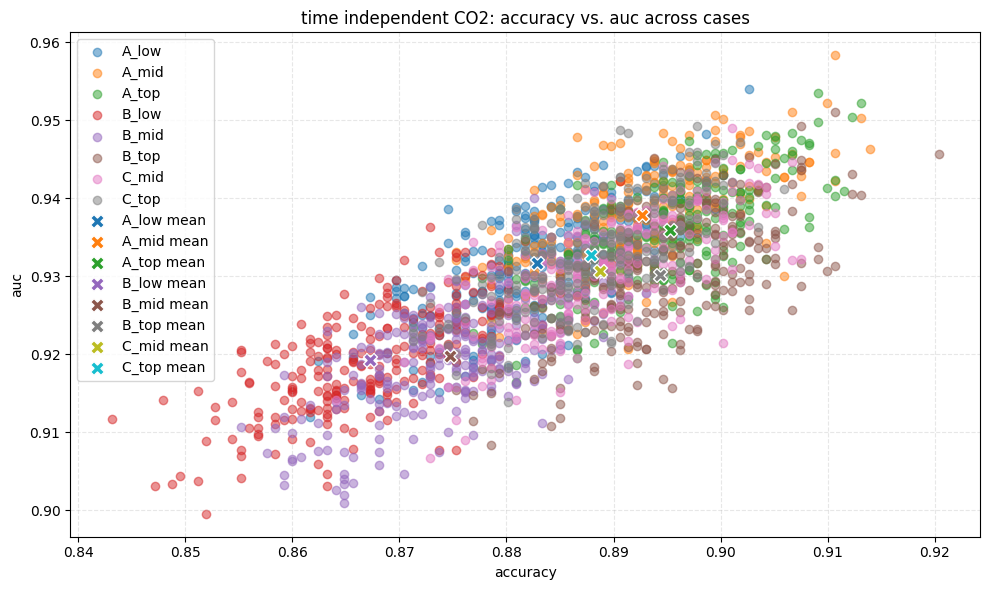

In [66]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

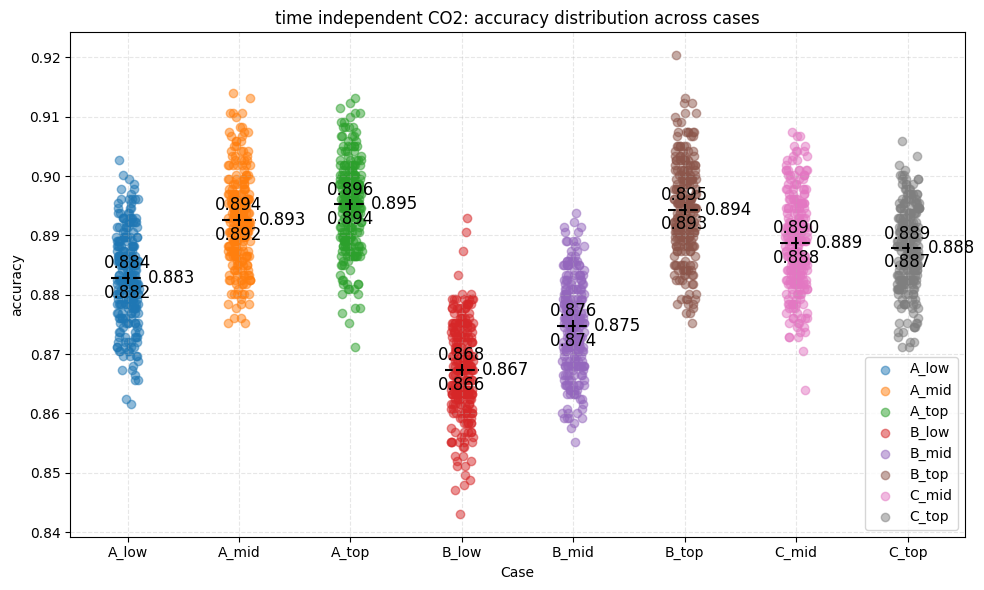

In [67]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

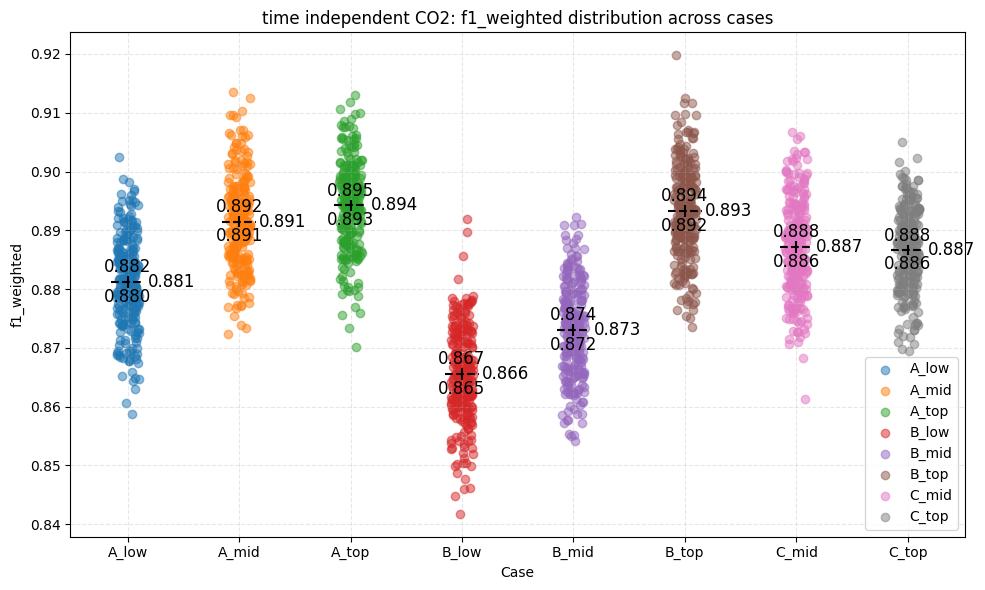

In [68]:
# plot f1 score
metric = "f1_weighted"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

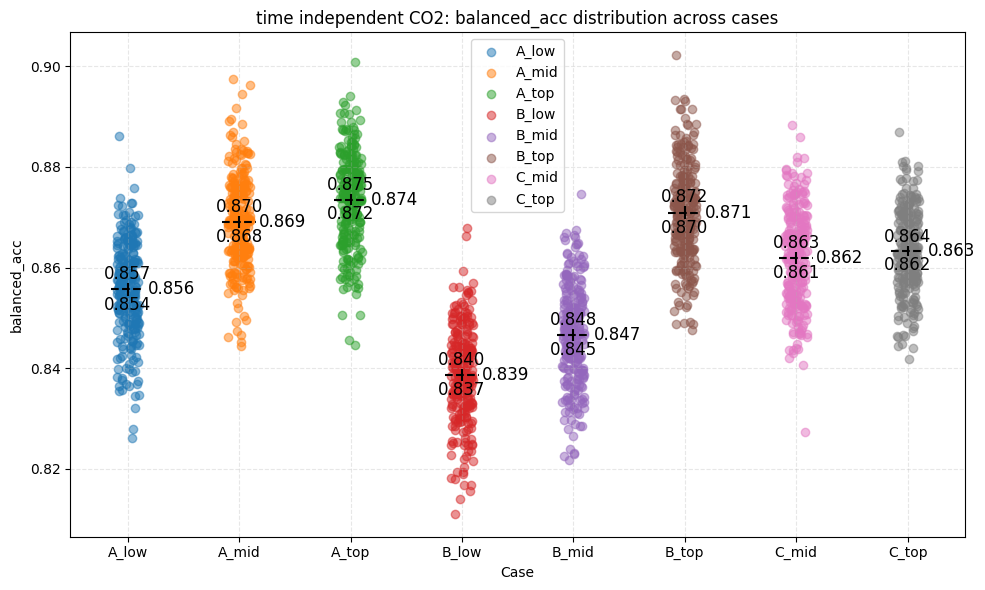

In [69]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

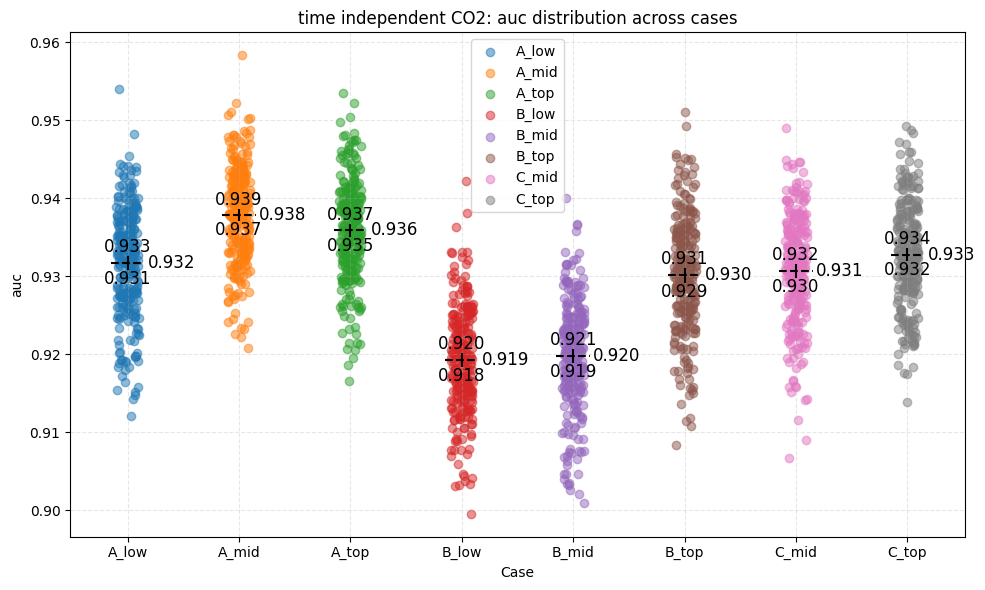

In [70]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [71]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for accuracy ===
A_low                    :	p = 0.5587	→	OK normal
A_mid                    :	p = 0.3141	→	OK normal
A_top                    :	p = 0.2018	→	OK normal
B_low                    :	p = 0.6308	→	OK normal
B_mid                    :	p = 0.1935	→	OK normal
B_top                    :	p = 0.8394	→	OK normal
C_mid                    :	p = 0.4005	→	OK normal
C_top                    :	p = 0.2368	→	OK normal

=== Normality test (Shapiro-Wilk) for accuracy ===
A_low                    :	p = 0.7152	→	OK normal
A_mid                    :	p = 0.1812	→	OK normal
A_top                    :	p = 0.0847	→	OK normal
B_low                    :	p = 0.1599	→	OK normal
B_mid                    :	p = 0.4040	→	OK normal
B_top                    :	p = 0.5651	→	OK normal
C_mid                    :	p = 0.3142	→	OK normal
C_top                    :	p = 0.2364	→	OK normal

=== Normality test (Anderson-Darling) for accuracy ===
A_low    

In [72]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for f1_weighted ===
A_low                    :	p = 0.5960	→	OK normal
A_mid                    :	p = 0.3706	→	OK normal
A_top                    :	p = 0.2176	→	OK normal
B_low                    :	p = 0.6150	→	OK normal
B_mid                    :	p = 0.1736	→	OK normal
B_top                    :	p = 0.8198	→	OK normal
C_mid                    :	p = 0.4261	→	OK normal
C_top                    :	p = 0.2627	→	OK normal

=== Normality test (Shapiro-Wilk) for f1_weighted ===
A_low                    :	p = 0.9008	→	OK normal
A_mid                    :	p = 0.4372	→	OK normal
A_top                    :	p = 0.1501	→	OK normal
B_low                    :	p = 0.2634	→	OK normal
B_mid                    :	p = 0.4086	→	OK normal
B_top                    :	p = 0.7991	→	OK normal
C_mid                    :	p = 0.4245	→	OK normal
C_top                    :	p = 0.4638	→	OK normal

=== Normality test (Anderson-Darling) for f1_weighted ===


In [73]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
A_low                    :	p = 0.2105	→	OK normal
A_mid                    :	p = 0.6182	→	OK normal
A_top                    :	p = 0.2716	→	OK normal
B_low                    :	p = 0.6119	→	OK normal
B_mid                    :	p = 0.5223	→	OK normal
B_top                    :	p = 0.7490	→	OK normal
C_mid                    :	p = 0.7177	→	OK normal
C_top                    :	p = 0.7126	→	OK normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
A_low                    :	p = 0.1935	→	OK normal
A_mid                    :	p = 0.5024	→	OK normal
A_top                    :	p = 0.3840	→	OK normal
B_low                    :	p = 0.6936	→	OK normal
B_mid                    :	p = 0.7540	→	OK normal
B_top                    :	p = 0.8486	→	OK normal
C_mid                    :	p = 0.1875	→	OK normal
C_top                    :	p = 0.8098	→	OK normal

=== Normality test (Anderson-Darling) for balanced_acc =

In [74]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for auc ===
A_low                    :	p = 0.2502	→	OK normal
A_mid                    :	p = 0.7523	→	OK normal
A_top                    :	p = 0.4545	→	OK normal
B_low                    :	p = 0.6944	→	OK normal
B_mid                    :	p = 0.1874	→	OK normal
B_top                    :	p = 0.7946	→	OK normal
C_mid                    :	p = 0.0446	→	not normal
C_top                    :	p = 0.6731	→	OK normal

=== Normality test (Shapiro-Wilk) for auc ===
A_low                    :	p = 0.0728	→	OK normal
A_mid                    :	p = 0.5465	→	OK normal
A_top                    :	p = 0.6377	→	OK normal
B_low                    :	p = 0.9056	→	OK normal
B_mid                    :	p = 0.0487	→	not normal
B_top                    :	p = 0.9132	→	OK normal
C_mid                    :	p = 0.0878	→	OK normal
C_top                    :	p = 0.5596	→	OK normal

=== Normality test (Anderson-Darling) for auc ===
A_low                 

### ANOVA

In [75]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time independent CO2

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2          F         p-unc      np2
  case      7 853.519615 408.216579 2.411983e-267 0.597023

Effect size (partial η², np2) = 0.5970 → large effect

=== Games-Howell post-hoc test for accuracy ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.882819 0.892631 -0.009812 0.000690 -14.213784 497.999663 0.000000e+00 -1.269404
A_low A_top 0.882819 0.895244 -0.012425 0.000674 -18.436029 496.842343 0.000000e+00 -1.646484
A_low B_low 0.882819 0.867276  0.015543 0.000698  22.259102 497.724444 9.769963e-15  1.987915
A_low B_mid 0.882819 0.874739  0.008080 0.000692  11.675670 497.982372 0.000000e+00  1.042730
A_low B_top 0.882819 0.894359 -0.011540 0.000703 -16.424546 497.373352 0.000000e+00 -1.466843
A_low C_mid 0.882819 0.888692 -0.005873 0.000705  -8.331191 497.128680 0.000000e+00 -0.744042
A_low C_top 0.882819 0.887916 -0.005097 0.000652  -7.813752 491.0

In [76]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted'
)

time independent CO2

=== Welch ANOVA for f1_weighted ===
Source  ddof1     ddof2          F         p-unc      np2
  case      7 853.50362 410.892502 2.839728e-268 0.598445

Effect size (partial η², np2) = 0.5984 → large effect

=== Games-Howell post-hoc test for f1_weighted ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.881218 0.891482 -0.010264 0.000705 -14.559527 497.982671 0.000000e+00 -1.300281
A_low A_top 0.881218 0.894296 -0.013078 0.000690 -18.953446 496.757102 0.000000e+00 -1.692693
A_low B_low 0.881218 0.865553  0.015666 0.000714  21.938515 497.808728 0.000000e+00  1.959284
A_low B_mid 0.881218 0.873037  0.008181 0.000712  11.493666 497.911687 2.209344e-14  1.026476
A_low B_top 0.881218 0.893203 -0.011985 0.000719 -16.670522 497.464846 1.048051e-13 -1.488810
A_low C_mid 0.881218 0.887124 -0.005906 0.000722  -8.182676 497.190161 1.101341e-13 -0.730778
A_low C_top 0.881218 0.886649 -0.005430 0.000666  -8.149512 4

In [77]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time independent CO2

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2          F         p-unc      np2
  case      7 853.434466 406.961008 6.821738e-267 0.594218

Effect size (partial η², np2) = 0.5942 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.855663 0.869118 -0.013455 0.000860 -15.648792 497.390073 0.000000e+00 -1.397562
A_low A_top 0.855663 0.873503 -0.017840 0.000856 -20.849003 496.989864 3.247402e-13 -1.861982
A_low B_low 0.855663 0.838609  0.017054 0.000865  19.705127 497.768279 2.279288e-13  1.759824
A_low B_mid 0.855663 0.846600  0.009063 0.000882  10.272217 497.855124 1.887379e-13  0.917391
A_low B_top 0.855663 0.870927 -0.015264 0.000877 -17.399464 497.983241 2.181588e-13 -1.553910
A_low C_mid 0.855663 0.861931 -0.006268 0.000876  -7.154361 497.995060 8.442047e-11 -0.638941
A_low C_top 0.855663 0.863261 -0.007598 0.000808  -9.4018

In [78]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time independent CO2

=== Welch ANOVA for auc ===
Source  ddof1      ddof2          F         p-unc      np2
  case      7 853.533044 248.910476 2.945593e-201 0.457852

Effect size (partial η², np2) = 0.4579 → large effect

=== Games-Howell post-hoc test for auc ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.931682 0.937807 -0.006125 0.000606 -10.107370 491.517154 3.140821e-13 -0.902669
A_low A_top 0.931682 0.935845 -0.004163 0.000617  -6.749602 495.147815 1.163403e-09 -0.602793
A_low B_low 0.931682 0.919211  0.012472 0.000629  19.826058 497.410216 0.000000e+00  1.770625
A_low B_mid 0.931682 0.919771  0.011911 0.000639  18.647622 497.994704 0.000000e+00  1.665381
A_low B_top 0.931682 0.930092  0.001590 0.000658   2.417085 496.561008 2.352924e-01  0.215865
A_low C_mid 0.931682 0.930672  0.001010 0.000641   1.575083 497.987856 7.651140e-01  0.140667
A_low C_top 0.931682 0.932719 -0.001036 0.000620  -1.672296 495.853893 7.05

## Time series - CO2

In [79]:
model = "time series CO2"
A_low = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_A_low_state_timeseries_co2.csv")
A_mid = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_A_mid_state_timeseries_co2.csv")
A_top = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_A_top_state_timeseries_co2.csv")
B_low = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_B_low_state_timeseries_co2.csv")
B_mid = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_B_mid_state_timeseries_co2.csv")
B_top = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_B_top_state_timeseries_co2.csv")
C_mid = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_C_mid_state_timeseries_co2.csv")
C_top = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_C_top_state_timeseries_co2.csv")


In [80]:
A_low.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.907641,0.004902,0.891429,0.904490,0.907755,0.911020,0.920816
f1,250.0,0.903992,0.004752,0.886809,0.901211,0.904110,0.907095,0.916162
balanced_acc,250.0,0.910156,0.004657,0.893638,0.907445,0.910381,0.913191,0.922057
auc,250.0,0.951357,0.005943,0.931888,0.947527,0.951435,0.956161,0.962341
feature_importance.A_low_CO2_scaled,250.0,0.001704,0.003298,-0.008735,-0.000327,0.001551,0.003755,0.015592
feature_importance.A_low_CO2_fd1_scaled,250.0,0.086349,0.035051,0.009959,0.061837,0.083469,0.102102,0.186041
feature_importance.A_low_CO2_fd2_scaled,250.0,0.113736,0.038910,0.032082,0.083551,0.110531,0.141286,0.216082
feature_importance.A_low_CO2_fd3_scaled,250.0,0.078857,0.040270,0.006612,0.049286,0.072857,0.103122,0.189551


In [81]:
A_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.838458,0.020532,0.799515,0.821342,0.837106,0.852061,0.903800
f1,250.0,0.841130,0.017259,0.809816,0.827006,0.839762,0.852426,0.898723
balanced_acc,250.0,0.846056,0.018942,0.810263,0.830387,0.844861,0.858485,0.906245
auc,250.0,0.932406,0.004146,0.922416,0.929253,0.932117,0.935650,0.942233
feature_importance.A_mid_CO2_scaled,250.0,-0.057449,0.014827,-0.084721,-0.069968,-0.058892,-0.047251,-0.011156
feature_importance.A_mid_CO2_fd1_scaled,250.0,0.111315,0.017078,0.068068,0.098808,0.111964,0.122676,0.159822
feature_importance.A_mid_CO2_fd2_scaled,250.0,0.146446,0.018267,0.082862,0.136217,0.147009,0.159276,0.190299
feature_importance.A_mid_CO2_fd3_scaled,250.0,0.132959,0.021812,0.083347,0.117967,0.131690,0.147009,0.205093


In [82]:
A_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.865322,0.059501,0.718367,0.820612,0.891429,0.912653,0.931429
f1,250.0,0.869947,0.048437,0.756528,0.831035,0.890173,0.908551,0.927959
balanced_acc,250.0,0.871537,0.055014,0.734942,0.830243,0.895931,0.914701,0.933307
auc,250.0,0.949830,0.010701,0.886396,0.945062,0.951463,0.955672,0.969426
feature_importance.A_top_CO2_scaled,250.0,-0.036471,0.036542,-0.137143,-0.064531,-0.022408,-0.008878,0.036490
feature_importance.A_top_CO2_fd1_scaled,250.0,0.093212,0.046755,0.001878,0.059510,0.088735,0.124020,0.231347
feature_importance.A_top_CO2_fd2_scaled,250.0,0.093441,0.044005,0.011265,0.060878,0.090327,0.119633,0.223837
feature_importance.A_top_CO2_fd3_scaled,250.0,0.087864,0.048504,-0.004408,0.050082,0.080082,0.117653,0.233388


In [83]:
B_low.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.899071,0.009136,0.847416,0.896637,0.900738,0.904020,0.918786
f1,250.0,0.897715,0.008484,0.854688,0.895285,0.899167,0.902212,0.915888
balanced_acc,250.0,0.902883,0.008723,0.855630,0.900478,0.904382,0.907440,0.921181
auc,250.0,0.948062,0.011267,0.894696,0.941294,0.950608,0.956463,0.968843
feature_importance.B_low_CO2_scaled,250.0,0.000767,0.007194,-0.046349,-0.000472,0.001805,0.003999,0.017063
feature_importance.B_low_CO2_fd1_scaled,250.0,0.100827,0.050358,0.000410,0.063987,0.095693,0.133942,0.239377
feature_importance.B_low_CO2_fd2_scaled,250.0,0.126571,0.047294,0.014356,0.090484,0.127153,0.162244,0.243642
feature_importance.B_low_CO2_fd3_scaled,250.0,0.063999,0.043924,-0.009598,0.030763,0.055619,0.087490,0.204102


In [84]:
B_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.909124,0.009832,0.849959,0.902927,0.910965,0.915911,0.927453
f1,250.0,0.907718,0.008780,0.857143,0.902434,0.909167,0.914031,0.925170
balanced_acc,250.0,0.912282,0.009094,0.857414,0.906797,0.914038,0.918774,0.929718
auc,250.0,0.953264,0.006862,0.917101,0.949435,0.953794,0.957826,0.968013
feature_importance.B_mid_CO2_scaled,250.0,-0.002542,0.005598,-0.041632,-0.004452,-0.002432,-0.000082,0.013273
feature_importance.B_mid_CO2_fd1_scaled,250.0,0.102823,0.046117,0.004122,0.068817,0.099753,0.134749,0.220775
feature_importance.B_mid_CO2_fd2_scaled,250.0,0.122603,0.043940,0.031575,0.092374,0.117642,0.153607,0.228195
feature_importance.B_mid_CO2_fd3_scaled,250.0,0.091017,0.049965,0.000412,0.053256,0.089613,0.121764,0.258945


In [85]:
B_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.917723,0.010929,0.838392,0.915505,0.919606,0.924528,0.938474
f1,250.0,0.915966,0.010004,0.847405,0.913478,0.917785,0.922034,0.935843
balanced_acc,250.0,0.921018,0.010224,0.847221,0.918573,0.922909,0.927135,0.940493
auc,250.0,0.964164,0.007086,0.921669,0.959520,0.964745,0.969566,0.976358
feature_importance.B_top_CO2_scaled,250.0,-0.003623,0.006102,-0.057916,-0.005312,-0.002871,-0.000246,0.008860
feature_importance.B_top_CO2_fd1_scaled,250.0,0.085097,0.044944,-0.009106,0.052194,0.077605,0.116961,0.189007
feature_importance.B_top_CO2_fd2_scaled,250.0,0.085370,0.049416,0.001477,0.045980,0.081378,0.122662,0.241099
feature_importance.B_top_CO2_fd3_scaled,250.0,0.088998,0.055169,0.003199,0.046001,0.079245,0.123175,0.258737


In [86]:
C_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.910681,0.002550,0.900894,0.909017,0.910642,0.912266,0.921202
f1,250.0,0.905105,0.002978,0.893543,0.903282,0.905009,0.906736,0.917165
balanced_acc,250.0,0.912008,0.002782,0.901296,0.910279,0.911942,0.913630,0.923419
auc,250.0,0.950091,0.005614,0.930854,0.946971,0.951010,0.953968,0.961663
feature_importance.C_mid_CO2_scaled,250.0,-0.000030,0.002729,-0.005118,-0.002031,-0.000406,0.001686,0.012185
feature_importance.C_mid_CO2_fd1_scaled,250.0,0.130674,0.035301,0.031032,0.106803,0.130504,0.151056,0.244192
feature_importance.C_mid_CO2_fd2_scaled,250.0,0.114194,0.039003,0.024370,0.085418,0.112998,0.137754,0.234687
feature_importance.C_mid_CO2_fd3_scaled,250.0,0.105502,0.045242,0.008773,0.071893,0.102234,0.136231,0.247116


In [87]:
C_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.910727,0.009415,0.857959,0.908571,0.913469,0.916735,0.928163
f1,250.0,0.907972,0.008465,0.862342,0.905629,0.910486,0.913256,0.924269
balanced_acc,250.0,0.913823,0.008595,0.865634,0.911617,0.916506,0.919130,0.929767
auc,250.0,0.948625,0.005867,0.911187,0.946368,0.949692,0.952212,0.960129
feature_importance.C_top_CO2_scaled,250.0,-0.000427,0.007105,-0.048571,-0.002755,0.000163,0.003429,0.020490
feature_importance.C_top_CO2_fd1_scaled,250.0,0.144958,0.044493,0.040490,0.113469,0.143184,0.174408,0.259918
feature_importance.C_top_CO2_fd2_scaled,250.0,0.158647,0.047907,0.030122,0.129224,0.160980,0.194612,0.279265
feature_importance.C_top_CO2_fd3_scaled,250.0,0.093921,0.047635,0.005959,0.056592,0.087959,0.127694,0.211918


In [88]:
A_low['case'] = 'A_low'
A_mid['case'] = 'A_mid'
A_top['case'] = 'A_top'
B_low['case'] = 'B_low'
B_mid['case'] = 'B_mid'
B_top['case'] = 'B_top'
C_mid['case'] = 'C_mid'
C_top['case'] = 'C_top'

metrics = ["case", "accuracy", "f1", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        A_low[metrics],
        A_mid[metrics],
        A_top[metrics],
        B_low[metrics],
        B_mid[metrics],
        B_top[metrics],
        C_mid[metrics],
        C_top[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          2000 non-null   object 
 1   accuracy      2000 non-null   float64
 2   f1            2000 non-null   float64
 3   balanced_acc  2000 non-null   float64
 4   auc           2000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 78.3+ KB


In [89]:
case_order = ['A_low', 'A_mid', 'A_top', 'B_low', 'B_mid', 'B_top', 'C_mid', 'C_top']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,A_low,A_low,A_low,A_low,A_low
accuracy,0.915102,0.909388,0.907755,0.906939,0.908571
f1,0.911414,0.906801,0.904156,0.903716,0.904437
balanced_acc,0.917391,0.912725,0.910318,0.909815,0.910693
auc,0.961746,0.956109,0.962341,0.94185,0.959748
x,0,0,0,0,0
x_jitter,0.07518,0.066296,0.09892,0.051237,0.053621


### plot

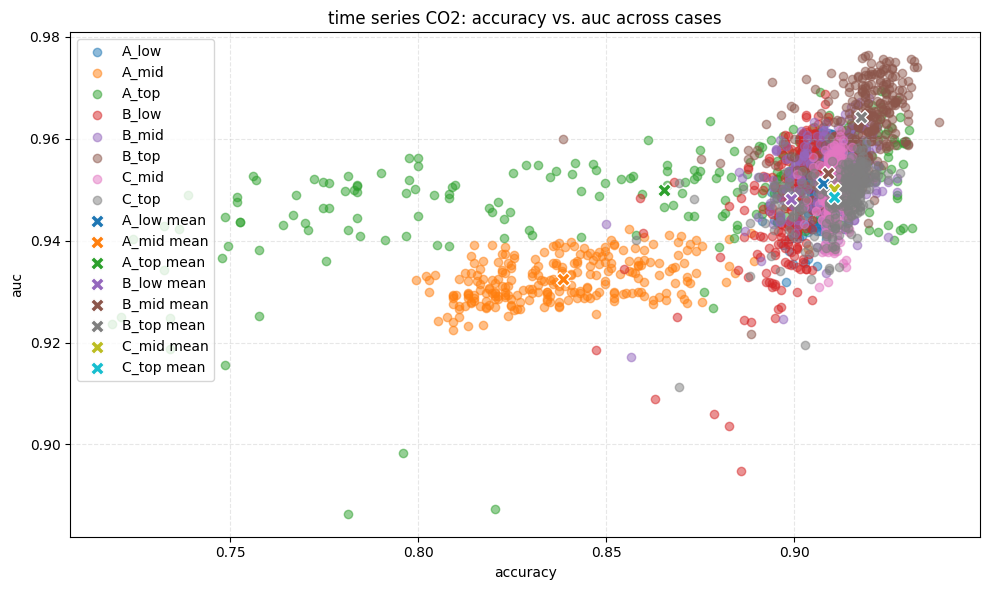

In [90]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

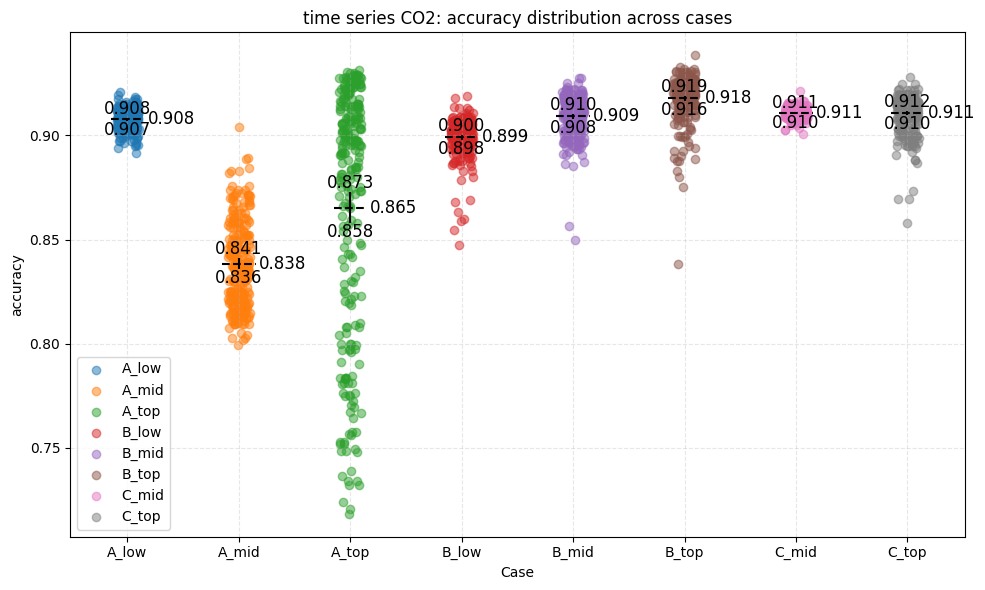

In [91]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

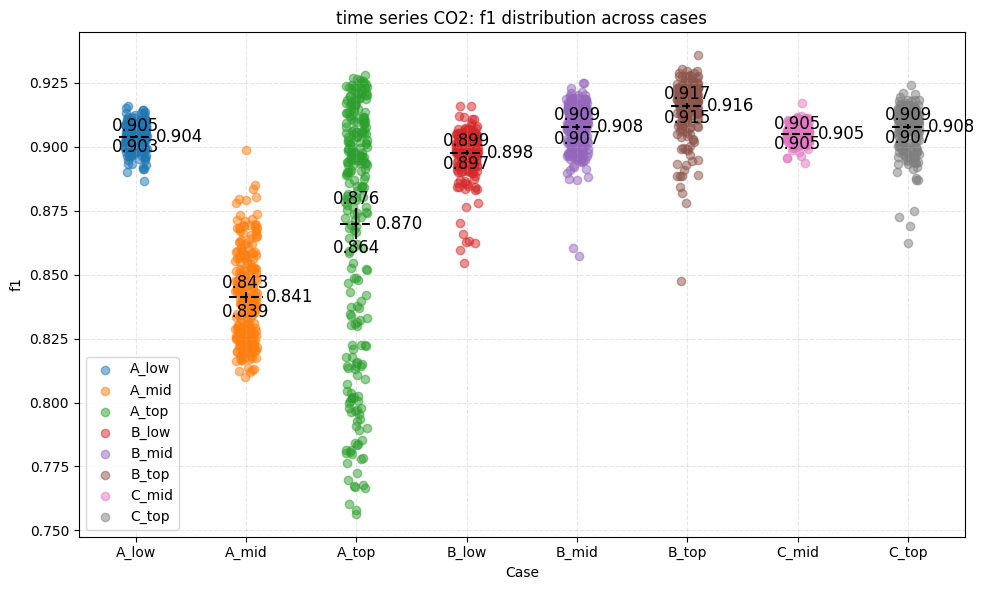

In [92]:
# plot f1 score
metric = "f1"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

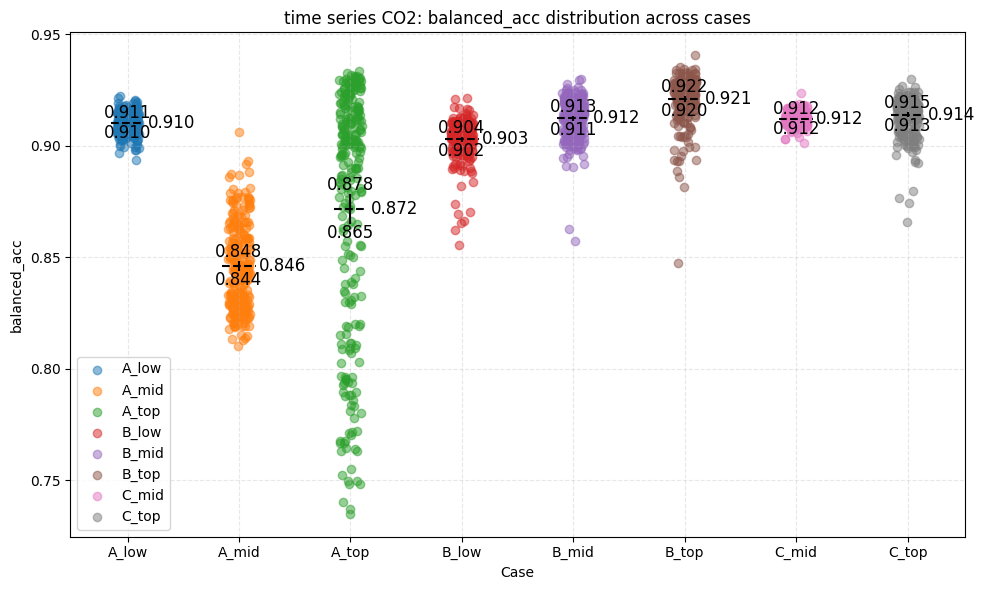

In [93]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

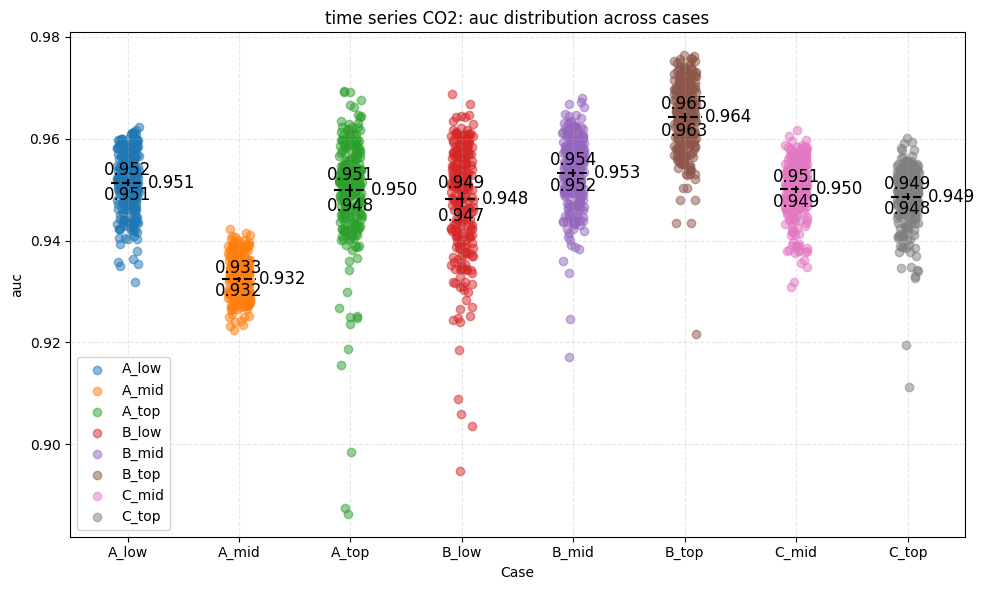

In [94]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [95]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time series CO2

=== Normality test (D’Agostino and Pearson) for accuracy ===
A_low                    :	p = 0.0215	→	not normal
A_mid                    :	p = 0.0045	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.0000	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0007	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for accuracy ===
A_low                    :	p = 0.0224	→	not normal
A_mid                    :	p = 0.0001	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.0000	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for accuracy ==

In [96]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1',
    group_order=case_order
)

time series CO2

=== Normality test (D’Agostino and Pearson) for f1 ===
A_low                    :	p = 0.0119	→	not normal
A_mid                    :	p = 0.0038	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.0000	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0005	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for f1 ===
A_low                    :	p = 0.0747	→	OK normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.0000	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0001	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for f1 ===
A_low            

In [97]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time series CO2

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
A_low                    :	p = 0.0132	→	not normal
A_mid                    :	p = 0.0041	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.0000	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0005	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
A_low                    :	p = 0.0710	→	OK normal
A_mid                    :	p = 0.0001	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.0000	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0002	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for bala

In [98]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time series CO2

=== Normality test (D’Agostino and Pearson) for auc ===
A_low                    :	p = 0.0133	→	not normal
A_mid                    :	p = 0.0008	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.0000	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
A_low                    :	p = 0.0003	→	not normal
A_mid                    :	p = 0.0008	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.0000	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for auc ===
A_low        

### ANOVA

In [99]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time series CO2

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2         F         p-unc      np2
  case      7 810.894931 522.65707 1.700084e-295 0.555962

Effect size (partial η², np2) = 0.5560 → large effect

=== Games-Howell post-hoc test for accuracy ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.907641 0.838458  0.069183 0.001335  51.821110 277.299627 2.143841e-13  4.628037
A_low A_top 0.907641 0.865322  0.042318 0.003776  11.207325 252.380362 0.000000e+00  1.000903
A_low B_low 0.907641 0.899071  0.008569 0.000656  13.068508 381.418865 5.329071e-14  1.167122
A_low B_mid 0.907641 0.909124 -0.001484 0.000695  -2.135258 365.602410 3.942414e-01 -0.190695
A_low B_top 0.907641 0.917723 -0.010082 0.000758 -13.307850 345.296173 7.771561e-15 -1.188497
A_low C_mid 0.907641 0.910681 -0.003040 0.000349  -8.698273 374.544382 0.000000e+00 -0.776825
A_low C_top 0.907641 0.910727 -0.003086 0.000671  -4.596444 374.781336 1

In [100]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1'
)

time series CO2

=== Welch ANOVA for f1 ===
Source  ddof1      ddof2          F         p-unc      np2
  case      7 824.436819 578.444787 5.201521e-313 0.599974

Effect size (partial η², np2) = 0.6000 → large effect

=== Games-Howell post-hoc test for f1 ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.903992 0.841130  0.062862 0.001132  55.524166 286.531691 0.000000e+00  4.958749
A_low A_top 0.903992 0.869947  0.034045 0.003078  11.060378 253.791980 5.806466e-14  0.987780
A_low B_low 0.903992 0.897715  0.006276 0.000615  10.205164 391.200773 0.000000e+00  0.911402
A_low B_mid 0.903992 0.907718 -0.003727 0.000631  -5.901878 383.321070 2.204189e-07 -0.527085
A_low B_top 0.903992 0.915966 -0.011974 0.000700 -17.094582 355.902891 0.000000e+00 -1.526682
A_low C_mid 0.903992 0.905105 -0.001113 0.000355  -3.138977 418.488437 3.809882e-02 -0.280336
A_low C_top 0.903992 0.907972 -0.003980 0.000614  -6.483000 391.733554 7.572732e-0

In [101]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time series CO2

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2          F         p-unc      np2
  case      7 819.890043 510.790005 6.935095e-294 0.559492

Effect size (partial η², np2) = 0.5595 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.910156 0.846056  0.064100 0.001234  51.959130 278.992680 3.075318e-14  4.640363
A_low A_top 0.910156 0.871537  0.038619 0.003492  11.059885 252.568435 1.052491e-13  0.987736
A_low B_low 0.910156 0.902883  0.007273 0.000625  11.630385 380.282967 2.030598e-13  1.038686
A_low B_mid 0.910156 0.912282 -0.002125 0.000646  -3.289324 371.203301 2.417008e-02 -0.293763
A_low B_top 0.910156 0.921018 -0.010861 0.000711 -15.286328 348.064249 0.000000e+00 -1.365191
A_low C_mid 0.910156 0.912008 -0.001852 0.000343  -5.397429 406.634938 3.184857e-06 -0.482033
A_low C_top 0.910156 0.913823 -0.003667 0.000618  -5.930496 38

In [102]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time series CO2

=== Welch ANOVA for auc ===
Source  ddof1      ddof2          F  p-unc      np2
  case      7 847.893577 713.082356    0.0 0.536797

Effect size (partial η², np2) = 0.5368 → large effect

=== Games-Howell post-hoc test for auc ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.951357 0.932406  0.018951 0.000458  41.351833 444.982940 1.474376e-13  3.693047
A_low A_top 0.951357 0.949830  0.001527 0.000774   1.972001 389.234165 5.022413e-01  0.176115
A_low B_low 0.951357 0.948062  0.003295 0.000806   4.089919 377.583262 1.354962e-03  0.365262
A_low B_mid 0.951357 0.953264 -0.001907 0.000574  -3.321814 488.041802 2.140680e-02 -0.296664
A_low B_top 0.951357 0.964164 -0.012807 0.000585 -21.895873 483.338842 0.000000e+00 -1.955475
A_low C_mid 0.951357 0.950091  0.001266 0.000517   2.447665 496.393818 2.209467e-01  0.218596
A_low C_top 0.951357 0.948625  0.002732 0.000528   5.171742 497.918679 9.274764e-06  0.461878


## Time independent - CO2temphum

In [103]:
model = "time independent CO2temphum"
A_low = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_A_low_state_timeindep_co2temphum.csv")
A_mid = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_A_mid_state_timeindep_co2temphum.csv")
A_top = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_A_top_state_timeindep_co2temphum.csv")
B_low = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_B_low_state_timeindep_co2temphum.csv")
B_mid = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_B_mid_state_timeindep_co2temphum.csv")
B_top = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_B_top_state_timeindep_co2temphum.csv")
C_mid = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_C_mid_state_timeindep_co2temphum.csv")
C_top = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_C_top_state_timeindep_co2temphum.csv")


In [104]:
A_low.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.980245,0.004221,0.968624,0.977474,0.980692,0.983105,0.990346
f1_weighted,250.0,0.980250,0.004220,0.968670,0.977443,0.980728,0.983108,0.990352
balanced_acc,250.0,0.977984,0.005018,0.964255,0.974388,0.978547,0.981543,0.989770
auc,250.0,0.995541,0.001594,0.990190,0.994473,0.995758,0.996674,0.999523
model_weights.random_forest,250.0,1.539195,0.386571,0.537092,1.264753,1.505994,1.775974,2.644673
model_weights.bagging_svc,250.0,0.785800,0.274210,-0.042191,0.604866,0.782616,0.989515,1.390336
model_weights.bagging_knn,250.0,0.077091,0.269014,-0.641978,-0.108865,0.095550,0.262613,0.799451
model_weights.gradient_boosting,250.0,5.321852,0.259043,4.587022,5.163678,5.309024,5.501679,5.952928


In [105]:
A_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.983144,0.003641,0.974256,0.980692,0.983105,0.986323,0.991955
f1_weighted,250.0,0.983142,0.003643,0.974203,0.980655,0.983111,0.986297,0.991960
balanced_acc,250.0,0.980892,0.004437,0.968284,0.977712,0.981139,0.983792,0.991364
auc,250.0,0.996774,0.001325,0.991879,0.996014,0.996953,0.997785,0.999266
model_weights.random_forest,250.0,2.174072,0.394791,1.267952,1.889624,2.110546,2.410067,3.411090
model_weights.bagging_svc,250.0,0.496343,0.322726,-0.428140,0.272496,0.481752,0.718967,1.306241
model_weights.bagging_knn,250.0,0.018758,0.275691,-0.786810,-0.170657,0.011016,0.228633,0.672775
model_weights.gradient_boosting,250.0,5.072337,0.275028,4.338176,4.891077,5.051931,5.229365,5.913899


In [106]:
A_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.984994,0.003675,0.973451,0.983105,0.985519,0.987128,0.995977
f1_weighted,250.0,0.984990,0.003674,0.973592,0.983077,0.985498,0.987136,0.995981
balanced_acc,250.0,0.982759,0.004385,0.971018,0.979842,0.982748,0.985554,0.996380
auc,250.0,0.997409,0.001128,0.993012,0.996756,0.997542,0.998207,0.999384
model_weights.random_forest,250.0,1.678211,0.357023,0.475682,1.459375,1.644341,1.893724,2.631092
model_weights.bagging_svc,250.0,0.445445,0.320693,-0.323563,0.243709,0.415064,0.667485,1.481146
model_weights.bagging_knn,250.0,0.235006,0.284817,-0.674603,0.054303,0.268059,0.440908,0.869031
model_weights.gradient_boosting,250.0,5.684878,0.258087,4.930302,5.497811,5.686593,5.856100,6.460581


In [107]:
B_low.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.979527,0.004114,0.967820,0.977474,0.979887,0.982301,0.989541
f1_weighted,250.0,0.979526,0.004118,0.967838,0.977408,0.979881,0.982301,0.989564
balanced_acc,250.0,0.976873,0.005219,0.962355,0.973183,0.976810,0.980556,0.990339
auc,250.0,0.995500,0.001572,0.989864,0.994437,0.995723,0.996714,0.999453
model_weights.random_forest,250.0,2.784920,0.374644,1.804276,2.531920,2.786761,3.022353,4.023121
model_weights.bagging_svc,250.0,0.357946,0.334058,-0.593058,0.163183,0.357311,0.591414,1.399319
model_weights.bagging_knn,250.0,-0.099333,0.294533,-0.931529,-0.290860,-0.086424,0.105865,0.907775
model_weights.gradient_boosting,250.0,5.035823,0.273144,4.344218,4.872604,5.036958,5.231141,5.779966


In [108]:
B_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.980019,0.003981,0.967015,0.977474,0.979887,0.983105,0.989541
f1_weighted,250.0,0.980031,0.003980,0.967121,0.977503,0.979950,0.983081,0.989544
balanced_acc,250.0,0.978067,0.004804,0.965040,0.975135,0.978233,0.981824,0.988604
auc,250.0,0.996194,0.001364,0.990859,0.995504,0.996370,0.997071,0.998891
model_weights.random_forest,250.0,2.571138,0.414586,1.543493,2.271863,2.549911,2.876393,3.576839
model_weights.bagging_svc,250.0,0.587903,0.363491,-0.370095,0.369832,0.614285,0.853588,1.439232
model_weights.bagging_knn,250.0,0.079069,0.277391,-1.047487,-0.103103,0.074685,0.274644,0.883593
model_weights.gradient_boosting,250.0,4.892052,0.282243,4.082797,4.711910,4.892174,5.106500,5.650587


In [109]:
B_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.982198,0.003590,0.972647,0.979887,0.982301,0.984714,0.991955
f1_weighted,250.0,0.982192,0.003592,0.972568,0.979830,0.982280,0.984719,0.991955
balanced_acc,250.0,0.979606,0.004421,0.965396,0.976173,0.979919,0.982902,0.991031
auc,250.0,0.996586,0.001475,0.989911,0.995929,0.996866,0.997563,0.999014
model_weights.random_forest,250.0,2.239601,0.413242,0.988332,1.917476,2.232077,2.537852,3.392998
model_weights.bagging_svc,250.0,0.728180,0.295364,0.000827,0.536064,0.748298,0.940545,1.392945
model_weights.bagging_knn,250.0,-0.043924,0.305986,-0.758256,-0.262679,-0.039617,0.166248,0.800496
model_weights.gradient_boosting,250.0,5.117483,0.255456,4.479038,4.959814,5.118065,5.307043,5.905712


In [110]:
C_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.983643,0.003892,0.970233,0.981496,0.983910,0.987128,0.995173
f1_weighted,250.0,0.983638,0.003890,0.970327,0.981451,0.983910,0.987095,0.995170
balanced_acc,250.0,0.981194,0.004455,0.965716,0.978638,0.981513,0.984795,0.994023
auc,250.0,0.996581,0.001443,0.992620,0.995628,0.996705,0.997687,0.999270
model_weights.random_forest,250.0,2.025376,0.411799,0.907193,1.753585,1.982821,2.279299,3.717636
model_weights.bagging_svc,250.0,0.770924,0.309950,-0.289941,0.596569,0.772413,0.980910,1.633838
model_weights.bagging_knn,250.0,0.107553,0.270317,-0.761073,-0.064949,0.113430,0.303749,0.974469
model_weights.gradient_boosting,250.0,5.614454,0.271858,4.817520,5.420524,5.618683,5.782920,6.361658


In [111]:
C_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.986378,0.003386,0.973451,0.983910,0.986323,0.988737,0.995977
f1_weighted,250.0,0.986378,0.003385,0.973441,0.983929,0.986335,0.988737,0.995974
balanced_acc,250.0,0.984624,0.004002,0.968067,0.981951,0.984809,0.987479,0.994631
auc,250.0,0.997496,0.001135,0.993059,0.996789,0.997689,0.998317,0.999499
model_weights.random_forest,250.0,2.332245,0.402058,1.270718,2.057235,2.296736,2.612261,3.803937
model_weights.bagging_svc,250.0,0.549482,0.328078,-0.296446,0.317946,0.543362,0.769194,1.291086
model_weights.bagging_knn,250.0,0.144550,0.332899,-0.779730,-0.089361,0.185248,0.408393,0.864939
model_weights.gradient_boosting,250.0,5.289782,0.249890,4.590059,5.104524,5.303386,5.471081,5.933396


In [112]:
A_low['case'] = 'A_low'
A_mid['case'] = 'A_mid'
A_top['case'] = 'A_top'
B_low['case'] = 'B_low'
B_mid['case'] = 'B_mid'
B_top['case'] = 'B_top'
C_mid['case'] = 'C_mid'
C_top['case'] = 'C_top'

metrics = ["case", "accuracy", "f1_weighted", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        A_low[metrics],
        A_mid[metrics],
        A_top[metrics],
        B_low[metrics],
        B_mid[metrics],
        B_top[metrics],
        C_mid[metrics],
        C_top[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          2000 non-null   object 
 1   accuracy      2000 non-null   float64
 2   f1_weighted   2000 non-null   float64
 3   balanced_acc  2000 non-null   float64
 4   auc           2000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 78.3+ KB


In [113]:
case_order = ['A_low', 'A_mid', 'A_top', 'B_low', 'B_mid', 'B_top', 'C_mid', 'C_top']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,A_low,A_low,A_low,A_low,A_low
accuracy,0.98391,0.975865,0.986323,0.976669,0.974256
f1_weighted,0.983945,0.975878,0.986327,0.97671,0.974239
balanced_acc,0.98439,0.973749,0.984976,0.976321,0.96998
auc,0.997813,0.996468,0.998591,0.994995,0.995161
x,0,0,0,0,0
x_jitter,-0.050643,0.031983,0.010018,-0.073566,-0.013739


### plot

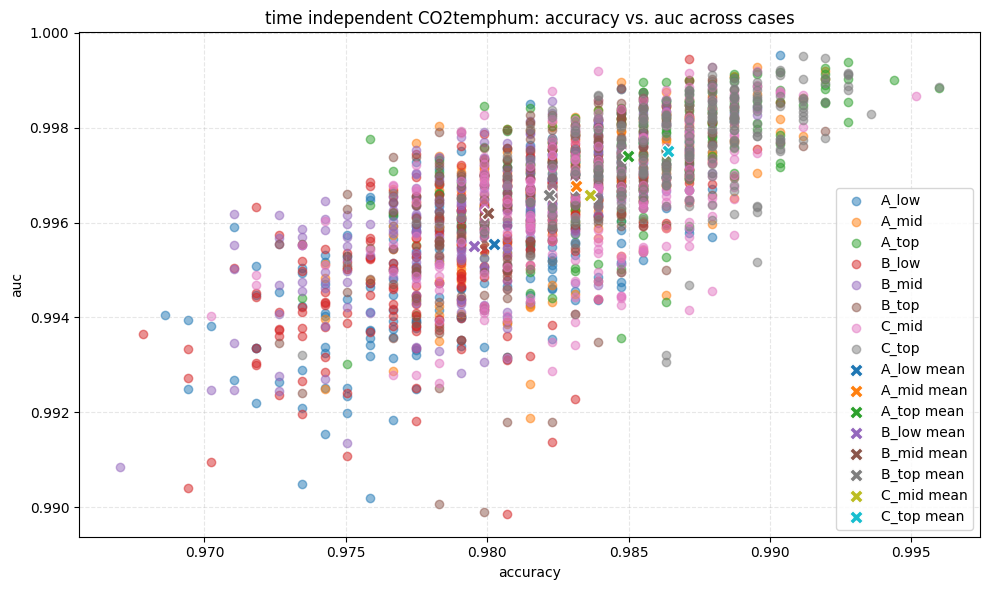

In [114]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

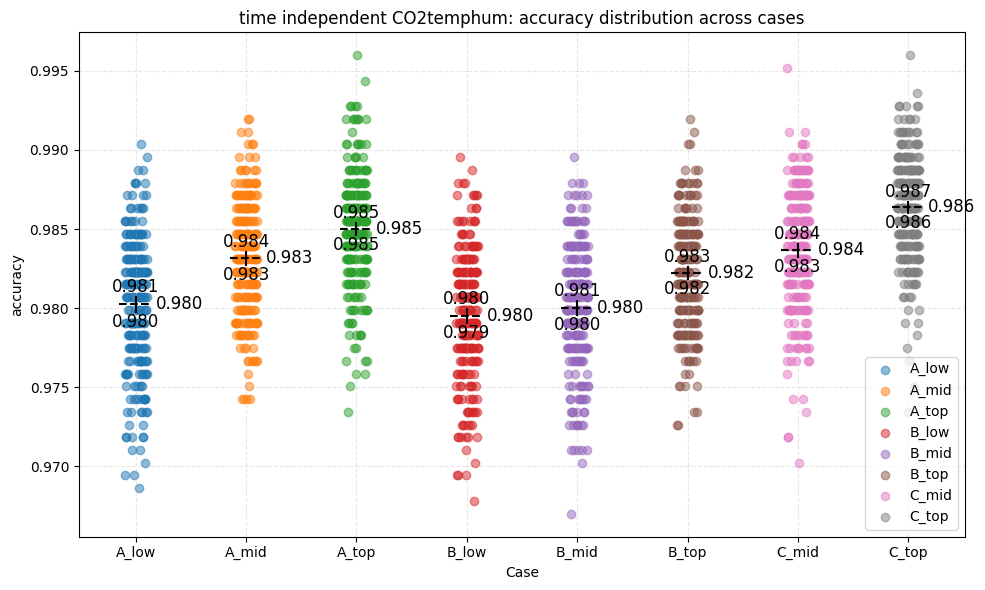

In [115]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

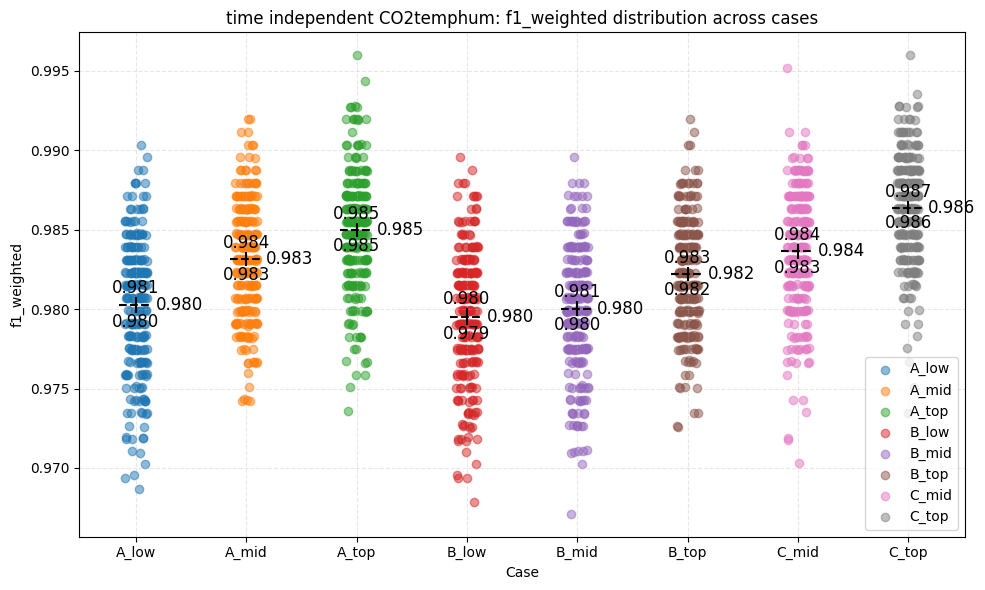

In [116]:
# plot f1 score
metric = "f1_weighted"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

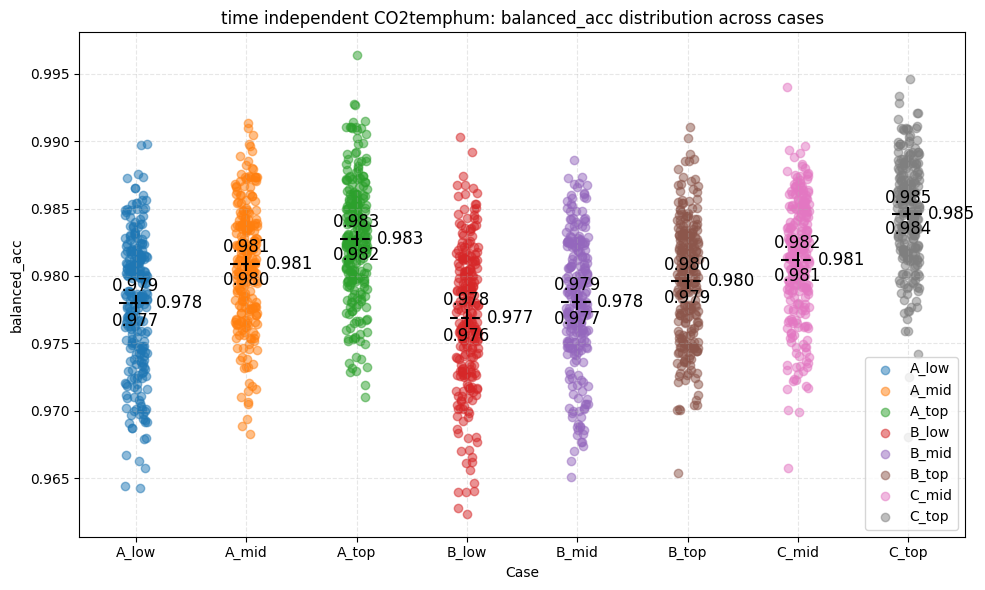

In [117]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

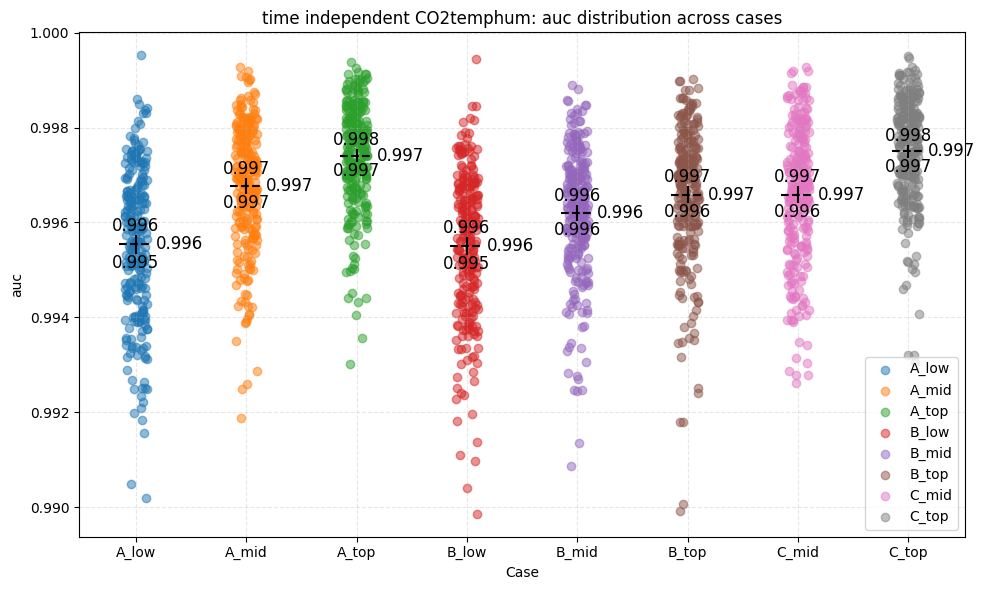

In [118]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [119]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time independent CO2temphum

=== Normality test (D’Agostino and Pearson) for accuracy ===
A_low                    :	p = 0.0961	→	OK normal
A_mid                    :	p = 0.2476	→	OK normal
A_top                    :	p = 0.1896	→	OK normal
B_low                    :	p = 0.3051	→	OK normal
B_mid                    :	p = 0.1017	→	OK normal
B_top                    :	p = 0.5473	→	OK normal
C_mid                    :	p = 0.0059	→	not normal
C_top                    :	p = 0.0021	→	not normal

=== Normality test (Shapiro-Wilk) for accuracy ===
A_low                    :	p = 0.0138	→	not normal
A_mid                    :	p = 0.0512	→	OK normal
A_top                    :	p = 0.0312	→	not normal
B_low                    :	p = 0.1050	→	OK normal
B_mid                    :	p = 0.0154	→	not normal
B_top                    :	p = 0.0474	→	not normal
C_mid                    :	p = 0.0009	→	not normal
C_top                    :	p = 0.0029	→	not normal

=== Normality test (Anderson-Darling) for accurac

In [120]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted',
    group_order=case_order
)

time independent CO2temphum

=== Normality test (D’Agostino and Pearson) for f1_weighted ===
A_low                    :	p = 0.0943	→	OK normal
A_mid                    :	p = 0.2478	→	OK normal
A_top                    :	p = 0.2104	→	OK normal
B_low                    :	p = 0.3057	→	OK normal
B_mid                    :	p = 0.1027	→	OK normal
B_top                    :	p = 0.5422	→	OK normal
C_mid                    :	p = 0.0066	→	not normal
C_top                    :	p = 0.0022	→	not normal

=== Normality test (Shapiro-Wilk) for f1_weighted ===
A_low                    :	p = 0.0173	→	not normal
A_mid                    :	p = 0.0769	→	OK normal
A_top                    :	p = 0.0439	→	not normal
B_low                    :	p = 0.1554	→	OK normal
B_mid                    :	p = 0.0216	→	not normal
B_top                    :	p = 0.0716	→	OK normal
C_mid                    :	p = 0.0012	→	not normal
C_top                    :	p = 0.0037	→	not normal

=== Normality test (Anderson-Darling) for f1

In [121]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time independent CO2temphum

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
A_low                    :	p = 0.0319	→	not normal
A_mid                    :	p = 0.2682	→	OK normal
A_top                    :	p = 0.9250	→	OK normal
B_low                    :	p = 0.2244	→	OK normal
B_mid                    :	p = 0.0619	→	OK normal
B_top                    :	p = 0.3993	→	OK normal
C_mid                    :	p = 0.0304	→	not normal
C_top                    :	p = 0.0002	→	not normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
A_low                    :	p = 0.0041	→	not normal
A_mid                    :	p = 0.2610	→	OK normal
A_top                    :	p = 0.8591	→	OK normal
B_low                    :	p = 0.2330	→	OK normal
B_mid                    :	p = 0.0080	→	not normal
B_top                    :	p = 0.1880	→	OK normal
C_mid                    :	p = 0.0060	→	not normal
C_top                    :	p = 0.0044	→	not normal

=== Normality test (Anderson-Darling) for 

In [122]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time independent CO2temphum

=== Normality test (D’Agostino and Pearson) for auc ===
A_low                    :	p = 0.0127	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.0001	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0103	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
A_low                    :	p = 0.0054	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.0001	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0004	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for auc ===
A

### ANOVA

In [123]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time independent CO2temphum

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2          F         p-unc      np2
  case      7 853.368157 108.240737 3.079289e-113 0.270486

Effect size (partial η², np2) = 0.2705 → large effect

=== Games-Howell post-hoc test for accuracy ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.980245 0.983144 -0.002899 0.000353  -8.223887 487.526264 2.055023e-13 -0.734458
A_low A_top 0.980245 0.984994 -0.004750 0.000354 -13.419941 488.733849 4.396483e-14 -1.198507
A_low B_low 0.980245 0.979527  0.000718 0.000373   1.925191 497.670434 5.341510e-01  0.171935
A_low B_mid 0.980245 0.980019  0.000225 0.000367   0.613846 496.311577 9.986934e-01  0.054821
A_low B_top 0.980245 0.982198 -0.001953 0.000350  -5.573957 485.492960 1.148573e-06 -0.497799
A_low C_mid 0.980245 0.983643 -0.003398 0.000363  -9.358669 494.759581 0.000000e+00 -0.835804
A_low C_top 0.980245 0.986378 -0.006134 0.000342 -17.92316

In [124]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted'
)

time independent CO2temphum

=== Welch ANOVA for f1_weighted ===
Source  ddof1      ddof2          F         p-unc      np2
  case      7 853.367671 107.988262 4.903697e-113 0.269955

Effect size (partial η², np2) = 0.2700 → large effect

=== Games-Howell post-hoc test for f1_weighted ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.980250 0.983142 -0.002892 0.000353  -8.203403 487.601627 7.760459e-14 -0.732629
A_low A_top 0.980250 0.984990 -0.004740 0.000354 -13.393109 488.757060 0.000000e+00 -1.196111
A_low B_low 0.980250 0.979526  0.000725 0.000373   1.943017 497.705683 5.218662e-01  0.173527
A_low B_mid 0.980250 0.980031  0.000219 0.000367   0.596178 496.297097 9.989184e-01  0.053243
A_low B_top 0.980250 0.982192 -0.001942 0.000350  -5.541045 485.607070 1.370438e-06 -0.494859
A_low C_mid 0.980250 0.983638 -0.003388 0.000363  -9.332705 494.737766 1.375566e-13 -0.833485
A_low C_top 0.980250 0.986378 -0.006128 0.000342 -17

In [125]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time independent CO2temphum

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2         F        p-unc      np2
  case      7 853.280558 84.792054 1.800340e-93 0.222645

Effect size (partial η², np2) = 0.2226 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.977984 0.980892 -0.002909 0.000424  -6.865521 490.627796 5.627783e-10 -0.613146
A_low A_top 0.977984 0.982759 -0.004775 0.000421 -11.328476 489.193742 0.000000e+00 -1.011723
A_low B_low 0.977984 0.976873  0.001110 0.000458   2.424881 497.233697 2.315754e-01  0.216561
A_low B_mid 0.977984 0.978067 -0.000083 0.000439  -0.189346 497.052122 9.999996e-01 -0.016910
A_low B_top 0.977984 0.979606 -0.001622 0.000423  -3.834968 490.195727 3.530843e-03 -0.342493
A_low C_mid 0.977984 0.981194 -0.003210 0.000424  -7.563167 491.098364 5.706990e-12 -0.675451
A_low C_top 0.977984 0.984624 -0.006640 0.000406 -16.3

In [126]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time independent CO2temphum

=== Welch ANOVA for auc ===
Source  ddof1      ddof2         F        p-unc      np2
  case      7 852.525793 76.359894 8.337888e-86 0.202986

Effect size (partial η², np2) = 0.2030 → large effect

=== Games-Howell post-hoc test for auc ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.995541 0.996774 -0.001233 0.000131  -9.403110 481.802754 1.447731e-13 -0.839773
A_low A_top 0.995541 0.997409 -0.001868 0.000124 -15.118428 448.356560 0.000000e+00 -1.350196
A_low B_low 0.995541 0.995500  0.000041 0.000142   0.287622 497.898294 9.999920e-01  0.025687
A_low B_mid 0.995541 0.996194 -0.000653 0.000133  -4.920086 486.385881 3.240635e-05 -0.439403
A_low B_top 0.995541 0.996586 -0.001044 0.000137  -7.603061 495.000632 4.075296e-12 -0.679014
A_low C_mid 0.995541 0.996581 -0.001040 0.000136  -7.645479 493.090284 3.053002e-12 -0.682802
A_low C_top 0.995541 0.997496 -0.001955 0.000124 -15.793101 449.800410 1

## Time series - CO2temphum

In [127]:
model = "time series CO2temphum"
A_low = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_A_low_state_timeseries_co2temphum.csv")
A_mid = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_A_mid_state_timeseries_co2temphum.csv")
A_top = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_A_top_state_timeseries_co2temphum.csv")
B_low = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_B_low_state_timeseries_co2temphum.csv")
B_mid = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_B_mid_state_timeseries_co2temphum.csv")
B_top = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_B_top_state_timeseries_co2temphum.csv")
C_mid = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_C_mid_state_timeseries_co2temphum.csv")
C_top = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_C_top_state_timeseries_co2temphum.csv")


In [128]:
A_low.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.935713,0.012939,0.876340,0.929926,0.936521,0.943941,0.963726
f1,250.0,0.930457,0.015317,0.854369,0.924699,0.932629,0.940243,0.960289
balanced_acc,250.0,0.935122,0.013845,0.870090,0.929436,0.936948,0.944102,0.962919
auc,250.0,0.975188,0.007841,0.940750,0.969399,0.975346,0.981072,0.991598
feature_importance.A_low_CO2_scaled,250.0,-0.001997,0.006848,-0.030668,-0.005008,-0.001566,0.002226,0.018219
feature_importance.A_low_CO2_fd1_scaled,250.0,0.005835,0.009706,-0.012119,-0.000701,0.004081,0.010800,0.044930
feature_importance.A_low_CO2_fd2_scaled,250.0,0.005112,0.010578,-0.019786,-0.001608,0.003751,0.009563,0.067601
feature_importance.A_low_CO2_fd3_scaled,250.0,0.002029,0.008531,-0.024155,-0.002638,0.001031,0.005523,0.030668


In [129]:
A_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.936052,0.008006,0.912266,0.931763,0.937449,0.942323,0.950447
f1,250.0,0.932582,0.007908,0.910000,0.928266,0.933678,0.938608,0.947277
balanced_acc,250.0,0.938079,0.007494,0.916369,0.934038,0.939200,0.943711,0.951923
auc,250.0,0.960982,0.002992,0.949402,0.959467,0.961280,0.962859,0.970074
feature_importance.A_mid_CO2_scaled,250.0,-0.000862,0.007477,-0.019740,-0.004691,-0.001219,0.002254,0.027376
feature_importance.A_mid_CO2_fd1_scaled,250.0,0.022669,0.012319,0.003574,0.013668,0.019334,0.028087,0.064013
feature_importance.A_mid_CO2_fd2_scaled,250.0,0.027604,0.013297,0.005280,0.016816,0.025630,0.035317,0.069943
feature_importance.A_mid_CO2_fd3_scaled,250.0,0.015766,0.012582,-0.002437,0.007250,0.011779,0.021507,0.074167


In [130]:
A_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.932984,0.020117,0.794094,0.927810,0.937654,0.944217,0.959803
f1,250.0,0.926696,0.021553,0.810566,0.920625,0.932073,0.940071,0.956676
balanced_acc,250.0,0.931822,0.020408,0.804732,0.926272,0.936600,0.944306,0.959648
auc,250.0,0.972906,0.007542,0.941228,0.968031,0.972638,0.977475,0.991830
feature_importance.A_top_CO2_scaled,250.0,-0.009370,0.013429,-0.126251,-0.012592,-0.007301,-0.002810,0.007875
feature_importance.A_top_CO2_fd1_scaled,250.0,0.016195,0.010744,-0.003610,0.008655,0.014110,0.022211,0.067842
feature_importance.A_top_CO2_fd2_scaled,250.0,0.020619,0.012948,-0.003856,0.012080,0.017637,0.027400,0.077358
feature_importance.A_top_CO2_fd3_scaled,250.0,0.016509,0.010623,-0.003527,0.008716,0.015176,0.022026,0.071862


In [131]:
B_low.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.941031,0.013521,0.903894,0.932063,0.941591,0.950290,0.975145
f1,250.0,0.938645,0.013562,0.902357,0.929319,0.939574,0.948106,0.973070
balanced_acc,250.0,0.942541,0.012935,0.906922,0.933631,0.943642,0.951663,0.974362
auc,250.0,0.981777,0.007582,0.959972,0.976720,0.982768,0.987734,0.995055
feature_importance.B_low_CO2_scaled,250.0,-0.002338,0.005930,-0.019884,-0.005302,-0.002237,0.000166,0.037283
feature_importance.B_low_CO2_fd1_scaled,250.0,-0.002819,0.009888,-0.023281,-0.008989,-0.004101,0.001553,0.057249
feature_importance.B_low_CO2_fd2_scaled,250.0,-0.001511,0.010684,-0.019967,-0.007767,-0.003148,0.002278,0.076719
feature_importance.B_low_CO2_fd3_scaled,250.0,-0.000158,0.007006,-0.019138,-0.004640,-0.000580,0.003811,0.028169


In [132]:
B_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.942822,0.011715,0.890894,0.937654,0.945037,0.949959,0.965546
f1,250.0,0.939104,0.013197,0.871745,0.934373,0.941991,0.946881,0.962963
balanced_acc,250.0,0.943516,0.012265,0.884709,0.938947,0.946248,0.950777,0.965602
auc,250.0,0.982404,0.006907,0.949779,0.978662,0.983539,0.987227,0.994330
feature_importance.B_mid_CO2_scaled,250.0,-0.002771,0.006388,-0.028794,-0.004573,-0.001887,0.000246,0.023790
feature_importance.B_mid_CO2_fd1_scaled,250.0,-0.000779,0.006220,-0.018294,-0.004594,-0.001600,0.002133,0.022067
feature_importance.B_mid_CO2_fd2_scaled,250.0,-0.001743,0.006609,-0.023134,-0.005496,-0.002133,0.000882,0.027564
feature_importance.B_mid_CO2_fd3_scaled,250.0,-0.000990,0.006263,-0.025677,-0.003568,-0.000738,0.001969,0.019606


In [133]:
B_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.950144,0.013083,0.841756,0.944698,0.951118,0.957746,0.972659
f1,250.0,0.947617,0.014849,0.809950,0.942330,0.948641,0.955497,0.970822
balanced_acc,250.0,0.951282,0.013396,0.834283,0.946110,0.952294,0.958672,0.972815
auc,250.0,0.982239,0.008176,0.944590,0.977215,0.983719,0.988556,0.994887
feature_importance.B_top_CO2_scaled,250.0,-0.000787,0.004694,-0.031980,-0.002278,-0.000373,0.001326,0.012842
feature_importance.B_top_CO2_fd1_scaled,250.0,0.000170,0.009221,-0.016073,-0.004536,-0.001450,0.002651,0.088070
feature_importance.B_top_CO2_fd2_scaled,250.0,-0.000597,0.009287,-0.015990,-0.005054,-0.001988,0.001388,0.086495
feature_importance.B_top_CO2_fd3_scaled,250.0,-0.000777,0.008852,-0.016653,-0.004640,-0.001740,0.001077,0.093538


In [134]:
C_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.924202,0.015394,0.801988,0.917150,0.924606,0.933720,0.953604
f1,250.0,0.922713,0.014064,0.820436,0.915770,0.923077,0.931408,0.951049
balanced_acc,250.0,0.926906,0.014447,0.812542,0.920160,0.927396,0.935658,0.954399
auc,250.0,0.967275,0.010451,0.901377,0.962738,0.969181,0.974222,0.986193
feature_importance.C_mid_CO2_scaled,250.0,-0.005197,0.010876,-0.073571,-0.008782,-0.004432,-0.000746,0.034383
feature_importance.C_mid_CO2_fd1_scaled,250.0,0.014801,0.020832,-0.010108,0.002154,0.007912,0.021852,0.168931
feature_importance.C_mid_CO2_fd2_scaled,250.0,0.011629,0.019740,-0.016156,-0.001885,0.005758,0.018227,0.093786
feature_importance.C_mid_CO2_fd3_scaled,250.0,0.007574,0.017176,-0.022535,-0.002548,0.003645,0.012096,0.090224


In [135]:
C_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,1.245000e+02,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,1.245000e+02,186.750000,249.000000
accuracy,250.0,0.926323,0.029463,0.543496,0.922121,9.304060e-01,0.937862,0.956089
f1,250.0,0.922221,0.031924,0.539683,0.917059,9.278079e-01,0.935484,0.954113
balanced_acc,250.0,0.927270,0.030192,0.545397,0.922105,9.322052e-01,0.939617,0.957511
auc,250.0,0.968878,0.021917,0.667706,0.965364,9.709947e-01,0.975589,0.991513
feature_importance.C_top_CO2_scaled,250.0,-0.001437,0.006590,-0.074565,-0.002817,-6.213753e-04,0.001201,0.007705
feature_importance.C_top_CO2_fd1_scaled,250.0,0.015503,0.012226,-0.020547,0.007042,1.354598e-02,0.023198,0.057249
feature_importance.C_top_CO2_fd2_scaled,250.0,0.015141,0.011977,-0.013007,0.006959,1.325601e-02,0.022784,0.052610
feature_importance.C_top_CO2_fd3_scaled,250.0,0.009533,0.010477,-0.017399,0.002568,7.829329e-03,0.015286,0.050787


In [136]:
A_low['case'] = 'A_low'
A_mid['case'] = 'A_mid'
A_top['case'] = 'A_top'
B_low['case'] = 'B_low'
B_mid['case'] = 'B_mid'
B_top['case'] = 'B_top'
C_mid['case'] = 'C_mid'
C_top['case'] = 'C_top'

metrics = ["case", "accuracy", "f1", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        A_low[metrics],
        A_mid[metrics],
        A_top[metrics],
        B_low[metrics],
        B_mid[metrics],
        B_top[metrics],
        C_mid[metrics],
        C_top[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          2000 non-null   object 
 1   accuracy      2000 non-null   float64
 2   f1            2000 non-null   float64
 3   balanced_acc  2000 non-null   float64
 4   auc           2000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 78.3+ KB


In [137]:
case_order = ['A_low', 'A_mid', 'A_top', 'B_low', 'B_mid', 'B_top', 'C_mid', 'C_top']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,A_low,A_low,A_low,A_low,A_low
accuracy,0.940643,0.962077,0.933223,0.949711,0.936521
f1,0.938144,0.95993,0.928128,0.946632,0.933906
balanced_acc,0.942291,0.962919,0.932739,0.950212,0.938206
auc,0.94075,0.981408,0.984642,0.976303,0.972692
x,0,0,0,0,0
x_jitter,0.02415,-0.052624,-0.063601,-0.091498,-0.043115


### plot

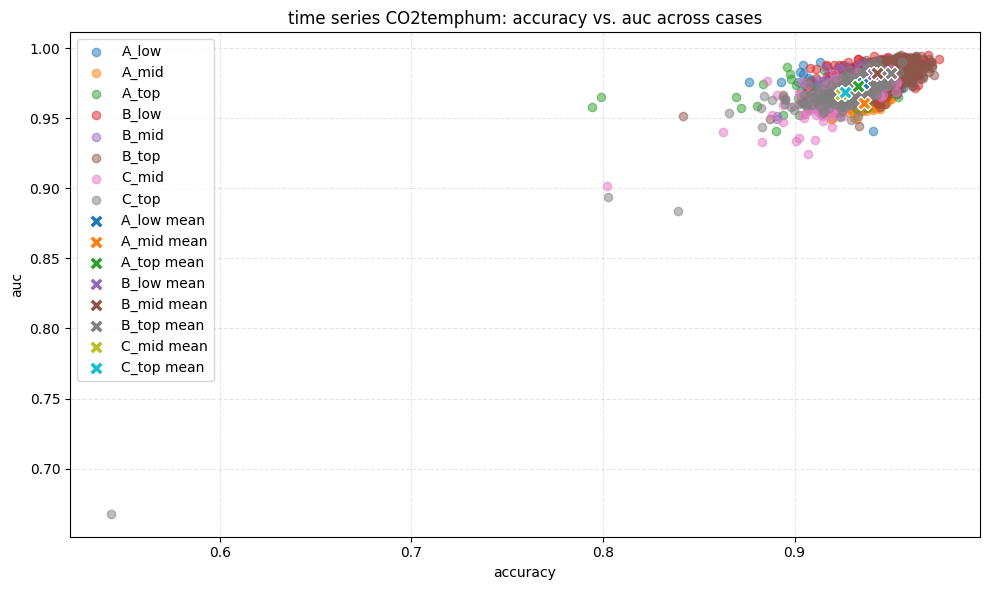

In [138]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

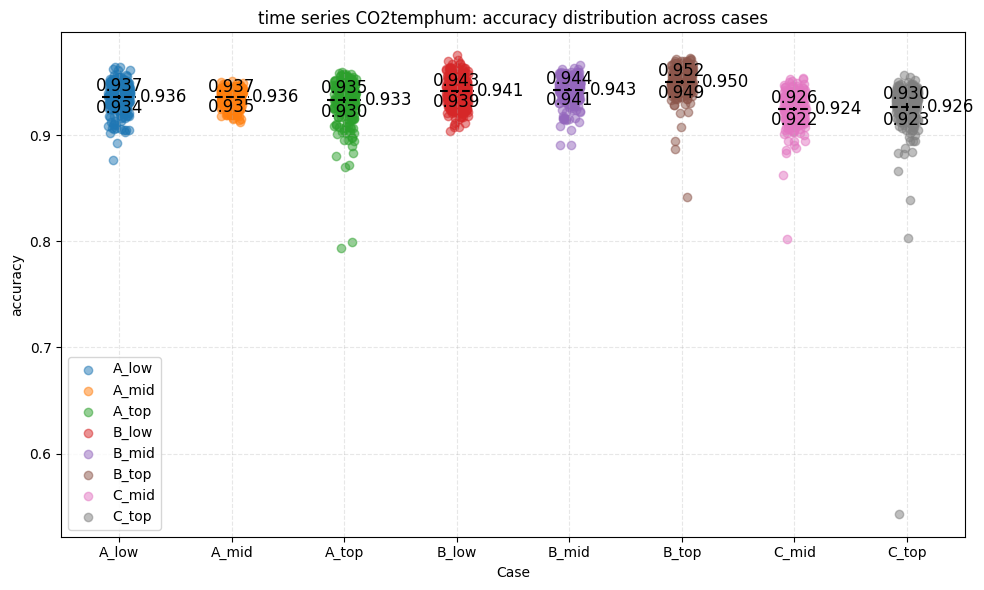

In [139]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

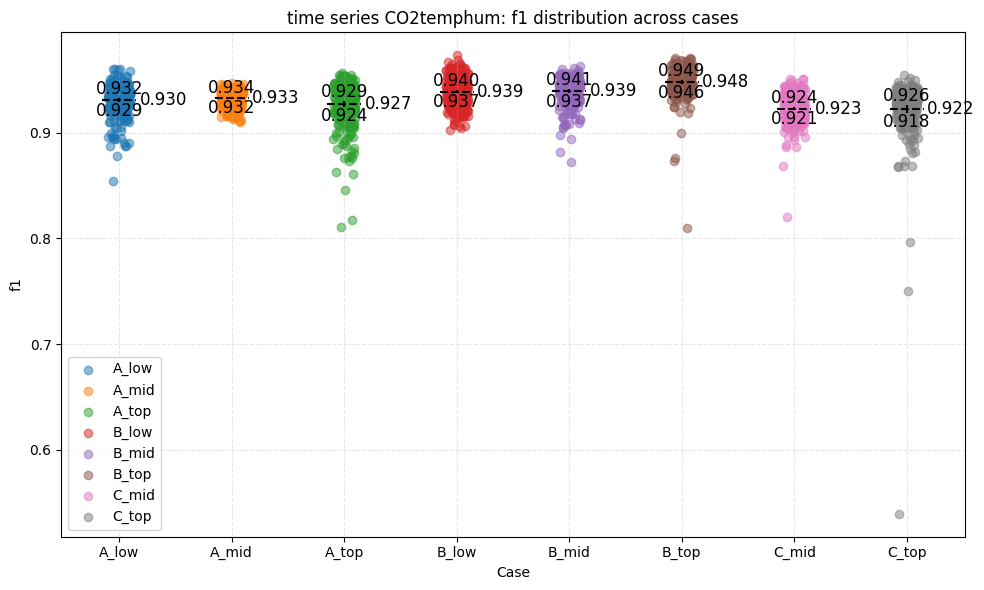

In [140]:
# plot f1 score
metric = "f1"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

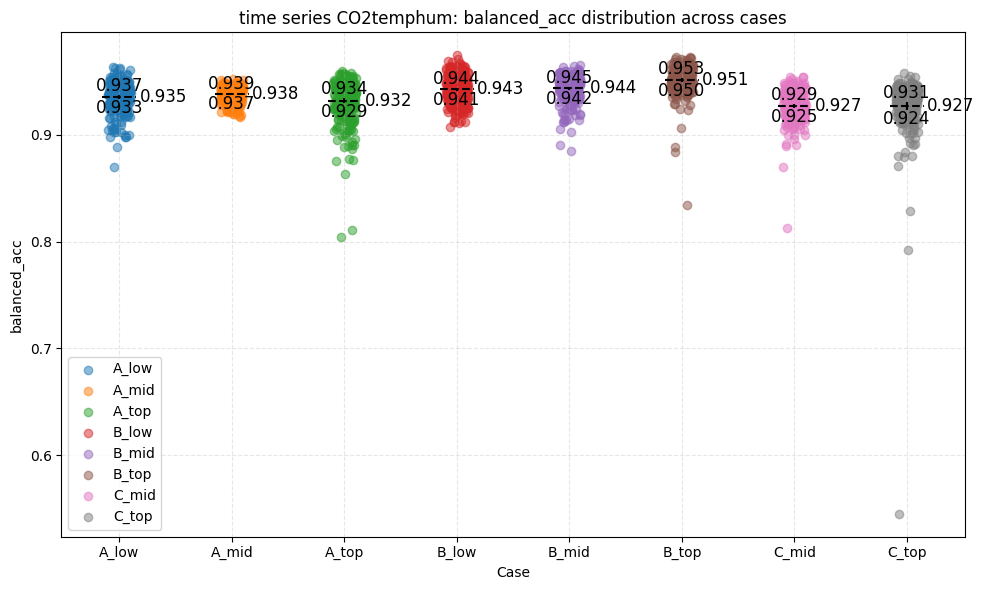

In [141]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

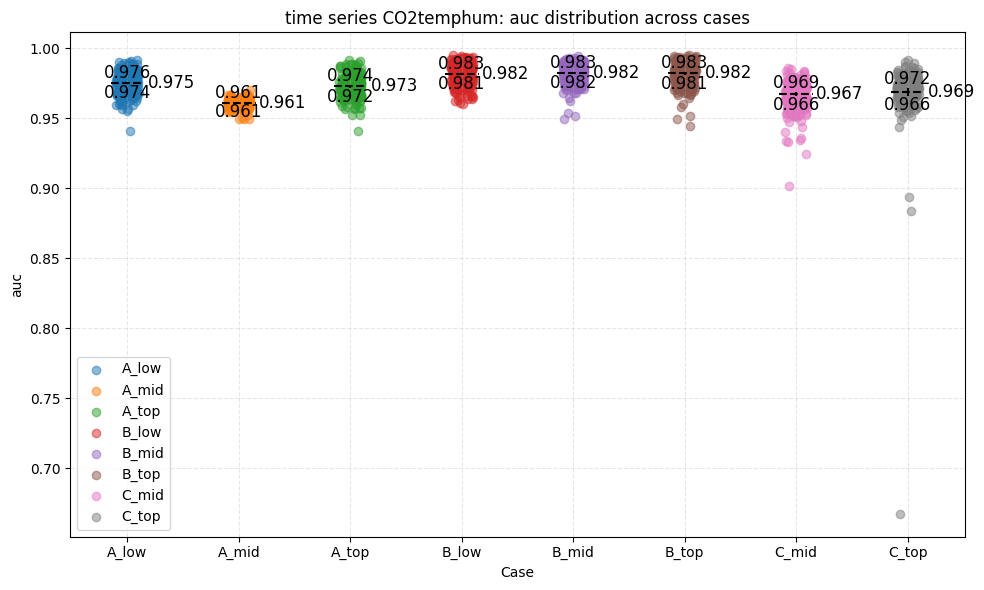

In [142]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [143]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time series CO2temphum

=== Normality test (D’Agostino and Pearson) for accuracy ===
A_low                    :	p = 0.0000	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.3878	→	OK normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for accuracy ===
A_low                    :	p = 0.0000	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.5401	→	OK normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for accura

In [144]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1',
    group_order=case_order
)

time series CO2temphum

=== Normality test (D’Agostino and Pearson) for f1 ===
A_low                    :	p = 0.0000	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.3771	→	OK normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for f1 ===
A_low                    :	p = 0.0000	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.4628	→	OK normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for f1 ===
A_low      

In [145]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time series CO2temphum

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
A_low                    :	p = 0.0000	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.2552	→	OK normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
A_low                    :	p = 0.0000	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.2706	→	OK normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) fo

In [146]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time series CO2temphum

=== Normality test (D’Agostino and Pearson) for auc ===
A_low                    :	p = 0.0076	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0291	→	not normal
B_low                    :	p = 0.0029	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
A_low                    :	p = 0.0029	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0116	→	not normal
B_low                    :	p = 0.0000	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for auc ===
A_low 

### ANOVA

In [147]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time series CO2temphum

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2         F        p-unc      np2
  case      7 845.732114 77.979595 3.798166e-87 0.187673

Effect size (partial η², np2) = 0.1877 → large effect

=== Games-Howell post-hoc test for accuracy ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.935713 0.936052 -0.000339 0.000962  -0.352154 415.283312 9.999678e-01 -0.031450
A_low A_top 0.935713 0.932984  0.002729 0.001513   1.803764 424.907895 6.178769e-01  0.161090
A_low B_low 0.935713 0.941031 -0.005318 0.001184  -4.492670 497.039609 2.339879e-04 -0.401231
A_low B_mid 0.935713 0.942822 -0.007109 0.001104  -6.439774 493.158539 7.949235e-09 -0.575123
A_low B_top 0.935713 0.950144 -0.014431 0.001164 -12.400439 497.939069 0.000000e+00 -1.107458
A_low C_mid 0.935713 0.924202  0.011511 0.001272   9.050696 483.691075 6.372680e-14  0.808299
A_low C_top 0.935713 0.926323  0.009390 0.002035   4.613784 341.598

In [148]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1'
)

time series CO2temphum

=== Welch ANOVA for f1 ===
Source  ddof1      ddof2         F        p-unc      np2
  case      7 843.513126 74.211897 1.279862e-83 0.177384

Effect size (partial η², np2) = 0.1774 → large effect

=== Games-Howell post-hoc test for f1 ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.930457 0.932582 -0.002126 0.001090  -1.949782 372.918883 5.175094e-01 -0.174131
A_low A_top 0.930457 0.926696  0.003761 0.001672   2.248875 449.402157 3.247188e-01  0.200842
A_low B_low 0.930457 0.938645 -0.008188 0.001294  -6.328120 490.802652 1.564482e-08 -0.565151
A_low B_mid 0.930457 0.939104 -0.008647 0.001279  -6.762144 487.341733 1.091515e-09 -0.603913
A_low B_top 0.930457 0.947617 -0.017161 0.001349 -12.718696 497.520285 0.000000e+00 -1.135881
A_low C_mid 0.930457 0.922713  0.007743 0.001315   5.887820 494.412611 2.015356e-07  0.525829
A_low C_top 0.930457 0.922221  0.008236 0.002239   3.677703 357.879021 6.540169

In [149]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time series CO2temphum

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2         F        p-unc      np2
  case      7 843.668553 75.343961 1.127374e-84 0.181855

Effect size (partial η², np2) = 0.1819 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.935122 0.938079 -0.002958 0.000996  -2.970485 383.365649 6.219311e-02 -0.265288
A_low A_top 0.935122 0.931822  0.003300 0.001560   2.115867 438.146870 4.062590e-01  0.188964
A_low B_low 0.935122 0.942541 -0.007419 0.001198  -6.191204 495.713043 3.500270e-08 -0.552924
A_low B_mid 0.935122 0.943516 -0.008395 0.001170  -7.175971 490.859488 7.468803e-11 -0.640871
A_low B_top 0.935122 0.951282 -0.016161 0.001218 -13.263530 497.457994 0.000000e+00 -1.184539
A_low C_mid 0.935122 0.926906  0.008215 0.001266   6.491328 497.101756 5.767607e-09  0.579727
A_low C_top 0.935122 0.927270  0.007851 0.002101   3.737405

In [150]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time series CO2temphum

=== Welch ANOVA for auc ===
Source  ddof1      ddof2          F         p-unc      np2
  case      7 827.424888 615.654005 5.928788e-323 0.333245

Effect size (partial η², np2) = 0.3332 → large effect

=== Games-Howell post-hoc test for auc ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.975188 0.960982  0.014206 0.000531  26.763862 319.981621 0.000000e+00  2.390226
A_low A_top 0.975188 0.972906  0.002282 0.000688   3.316672 497.246904 2.174079e-02  0.296205
A_low B_low 0.975188 0.981777 -0.006589 0.000690  -9.552298 497.436456 0.000000e+00 -0.853096
A_low B_mid 0.975188 0.982404 -0.007216 0.000661 -10.918634 490.196891 0.000000e+00 -0.975121
A_low B_top 0.975188 0.982239 -0.007051 0.000716  -9.840950 497.130760 2.887690e-13 -0.878875
A_low C_mid 0.975188 0.967275  0.007912 0.000826   9.575438 461.883797 0.000000e+00  0.855163
A_low C_top 0.975188 0.968878  0.006309 0.001472   4.285716 311.718478 6.

## Time independent - temphum

In [151]:
model = "time independent temphum"
A_low = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_A_low_state_timeindep_temphum.csv")
A_mid = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_A_mid_state_timeindep_temphum.csv")
A_top = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_A_top_state_timeindep_temphum.csv")
B_low = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_B_low_state_timeindep_temphum.csv")
B_mid = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_B_mid_state_timeindep_temphum.csv")
B_top = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_B_top_state_timeindep_temphum.csv")
C_mid = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_C_mid_state_timeindep_temphum.csv")
C_top = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_C_top_state_timeindep_temphum.csv")


In [152]:
A_low.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.972776,0.004988,0.960579,0.969429,0.972647,0.975865,0.985519
f1_weighted,250.0,0.972760,0.004996,0.960512,0.969400,0.972615,0.975903,0.985511
balanced_acc,250.0,0.968735,0.006007,0.951326,0.964743,0.968316,0.972728,0.983575
auc,250.0,0.994506,0.001657,0.988880,0.993499,0.994577,0.995656,0.998018
model_weights.random_forest,250.0,1.619635,0.347630,0.536386,1.407899,1.614732,1.811502,2.603668
model_weights.bagging_svc,250.0,0.261544,0.288149,-0.475230,0.059904,0.252400,0.453929,1.122877
model_weights.bagging_knn,250.0,-0.031446,0.275466,-0.909983,-0.220276,-0.022935,0.171538,0.785795
model_weights.gradient_boosting,250.0,5.262839,0.256216,4.352875,5.100061,5.251882,5.413619,6.064700


In [153]:
A_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.976817,0.004331,0.962993,0.974256,0.977072,0.979887,0.987128
f1_weighted,250.0,0.976798,0.004335,0.962993,0.974192,0.977050,0.979853,0.987120
balanced_acc,250.0,0.973012,0.005242,0.956129,0.969783,0.973578,0.976558,0.986226
auc,250.0,0.995852,0.001645,0.987608,0.994997,0.996063,0.997047,0.998537
model_weights.random_forest,250.0,2.217976,0.358158,1.308014,1.983750,2.234581,2.444636,3.198068
model_weights.bagging_svc,250.0,1.202008,0.270307,0.543881,1.028301,1.192477,1.387228,1.902763
model_weights.bagging_knn,250.0,-0.510140,0.287842,-1.367892,-0.708339,-0.523334,-0.318293,0.201145
model_weights.gradient_boosting,250.0,4.504025,0.246330,3.861939,4.341566,4.501930,4.660138,5.238206


In [154]:
A_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.977010,0.004105,0.967015,0.974256,0.977474,0.979887,0.987128
f1_weighted,250.0,0.977003,0.004108,0.966842,0.974096,0.977420,0.979890,0.987136
balanced_acc,250.0,0.973727,0.004989,0.958112,0.970100,0.973716,0.977152,0.986047
auc,250.0,0.995393,0.001501,0.990132,0.994482,0.995511,0.996505,0.998942
model_weights.random_forest,250.0,1.319137,0.339444,-0.096146,1.090923,1.323344,1.531065,2.226594
model_weights.bagging_svc,250.0,1.284357,0.236054,0.645828,1.127436,1.276911,1.424978,2.052083
model_weights.bagging_knn,250.0,0.185187,0.319126,-0.670199,-0.044386,0.191392,0.413633,1.043336
model_weights.gradient_boosting,250.0,4.756630,0.265648,3.982223,4.561953,4.727481,4.934000,5.735354


In [155]:
B_low.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.970700,0.004863,0.954143,0.967820,0.970233,0.974256,0.982301
f1_weighted,250.0,0.970689,0.004876,0.953919,0.967733,0.970281,0.974248,0.982290
balanced_acc,250.0,0.966610,0.006089,0.944761,0.962893,0.966279,0.971306,0.979558
auc,250.0,0.993725,0.001524,0.988947,0.992808,0.993767,0.994609,0.997254
model_weights.random_forest,250.0,1.809039,0.356617,0.900747,1.532173,1.820978,2.059299,2.770938
model_weights.bagging_svc,250.0,1.030699,0.252787,0.306606,0.872674,1.032295,1.180416,2.023045
model_weights.bagging_knn,250.0,0.070809,0.252494,-0.580347,-0.109353,0.091302,0.242898,0.655519
model_weights.gradient_boosting,250.0,4.707640,0.254831,3.828303,4.563551,4.721736,4.882176,5.264001


In [156]:
B_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.975418,0.004324,0.957361,0.972647,0.975060,0.978278,0.985519
f1_weighted,250.0,0.975412,0.004330,0.957377,0.972587,0.975114,0.978294,0.985529
balanced_acc,250.0,0.972053,0.005365,0.949706,0.968358,0.972341,0.975911,0.984354
auc,250.0,0.994792,0.001592,0.989654,0.993756,0.994892,0.995829,0.998739
model_weights.random_forest,250.0,1.604953,0.379422,0.564385,1.364840,1.574410,1.815087,2.730428
model_weights.bagging_svc,250.0,1.378747,0.267729,0.715882,1.190961,1.372397,1.578278,2.103257
model_weights.bagging_knn,250.0,0.213353,0.293532,-0.691899,0.002568,0.216763,0.412601,0.959235
model_weights.gradient_boosting,250.0,4.935751,0.267908,4.136425,4.762156,4.930962,5.100869,5.605578


In [157]:
B_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.978996,0.004193,0.966211,0.975865,0.979083,0.981496,0.990346
f1_weighted,250.0,0.978969,0.004204,0.966130,0.975819,0.979031,0.981480,0.990334
balanced_acc,250.0,0.975074,0.005286,0.959852,0.971236,0.975039,0.978336,0.987946
auc,250.0,0.995723,0.001558,0.989877,0.994889,0.995972,0.996843,0.998664
model_weights.random_forest,250.0,1.833908,0.376428,0.590081,1.597757,1.805598,2.062644,3.048672
model_weights.bagging_svc,250.0,1.361809,0.272218,0.607569,1.149825,1.360529,1.545796,2.075277
model_weights.bagging_knn,250.0,-0.172027,0.310680,-1.125481,-0.365648,-0.194679,0.042226,0.861698
model_weights.gradient_boosting,250.0,4.817171,0.239931,4.046292,4.675155,4.813820,4.971267,5.507312


In [158]:
C_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.976428,0.004623,0.961384,0.973451,0.976669,0.979887,0.987128
f1_weighted,250.0,0.976417,0.004629,0.961252,0.973478,0.976655,0.979855,0.987145
balanced_acc,250.0,0.972962,0.005618,0.952403,0.969645,0.973147,0.977215,0.986521
auc,250.0,0.995201,0.001820,0.986989,0.994101,0.995517,0.996503,0.998686
model_weights.random_forest,250.0,2.044330,0.354758,1.117853,1.822016,2.036696,2.294359,3.061203
model_weights.bagging_svc,250.0,0.731292,0.281945,-0.085281,0.572196,0.754526,0.910494,1.576955
model_weights.bagging_knn,250.0,-0.440423,0.301223,-1.173933,-0.642631,-0.436305,-0.250720,0.385699
model_weights.gradient_boosting,250.0,4.826883,0.241741,3.986500,4.686499,4.838273,4.982836,5.422336


In [159]:
C_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.979656,0.004003,0.965406,0.977474,0.979887,0.982301,0.988737
f1_weighted,250.0,0.979645,0.004008,0.965418,0.977381,0.979842,0.982309,0.988712
balanced_acc,250.0,0.976520,0.004930,0.960127,0.973691,0.976462,0.980184,0.987333
auc,250.0,0.996228,0.001461,0.989768,0.995518,0.996475,0.997247,0.999192
model_weights.random_forest,250.0,2.126227,0.387460,1.097657,1.850795,2.106988,2.383003,3.104375
model_weights.bagging_svc,250.0,0.977740,0.304008,0.229582,0.783752,0.975118,1.181776,1.780539
model_weights.bagging_knn,250.0,0.073386,0.338016,-0.747002,-0.158566,0.059293,0.308981,1.065890
model_weights.gradient_boosting,250.0,4.759022,0.265491,4.116703,4.594734,4.749750,4.927653,5.738251


In [160]:
A_low['case'] = 'A_low'
A_mid['case'] = 'A_mid'
A_top['case'] = 'A_top'
B_low['case'] = 'B_low'
B_mid['case'] = 'B_mid'
B_top['case'] = 'B_top'
C_mid['case'] = 'C_mid'
C_top['case'] = 'C_top'

metrics = ["case", "accuracy", "f1_weighted", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        A_low[metrics],
        A_mid[metrics],
        A_top[metrics],
        B_low[metrics],
        B_mid[metrics],
        B_top[metrics],
        C_mid[metrics],
        C_top[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          2000 non-null   object 
 1   accuracy      2000 non-null   float64
 2   f1_weighted   2000 non-null   float64
 3   balanced_acc  2000 non-null   float64
 4   auc           2000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 78.3+ KB


In [161]:
case_order = ['A_low', 'A_mid', 'A_top', 'B_low', 'B_mid', 'B_top', 'C_mid', 'C_top']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,A_low,A_low,A_low,A_low,A_low
accuracy,0.979083,0.965406,0.971038,0.969429,0.971842
f1_weighted,0.979117,0.965357,0.971021,0.969429,0.971833
balanced_acc,0.978471,0.960151,0.96697,0.966647,0.967548
auc,0.996805,0.993916,0.995708,0.994662,0.993938
x,0,0,0,0,0
x_jitter,0.074248,-0.02876,-0.039128,-0.025751,-0.054253


### plot

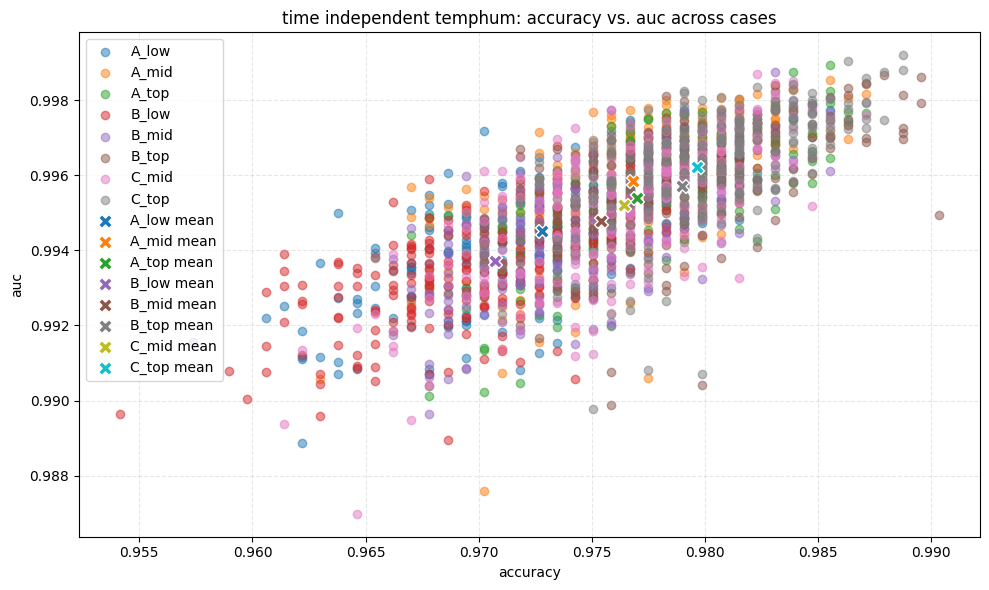

In [162]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

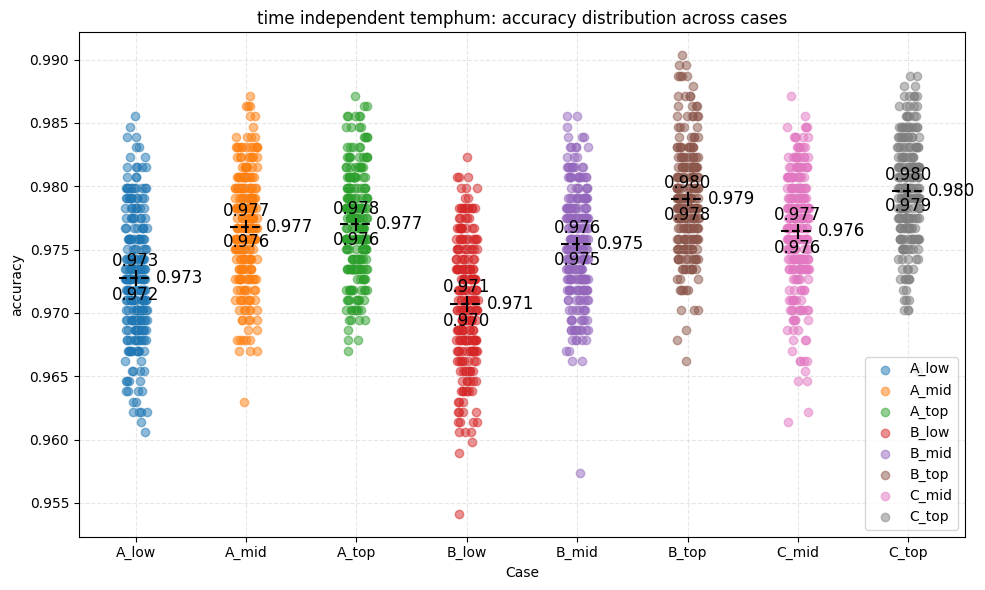

In [163]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

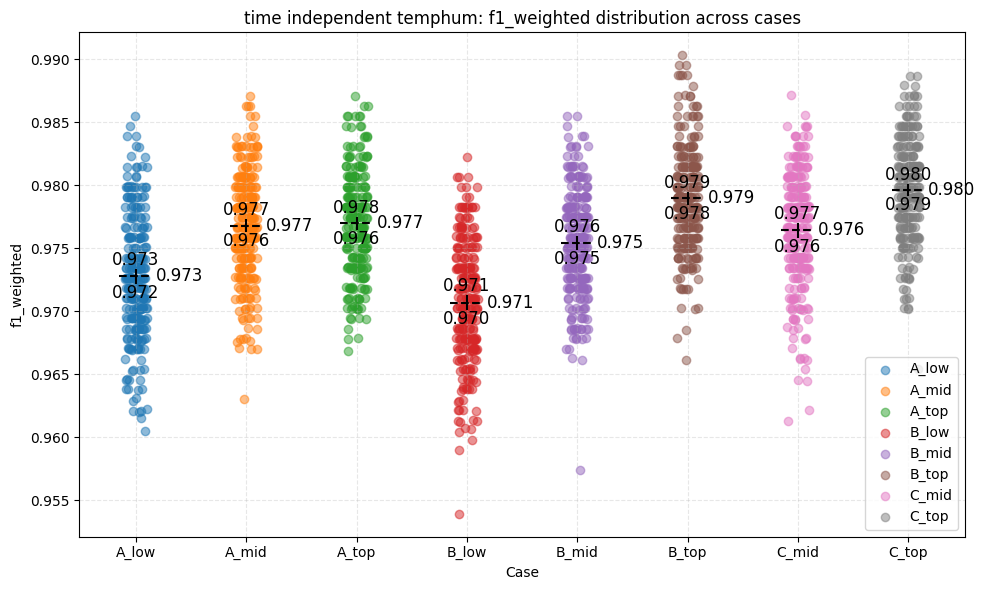

In [164]:
# plot f1 score
metric = "f1_weighted"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

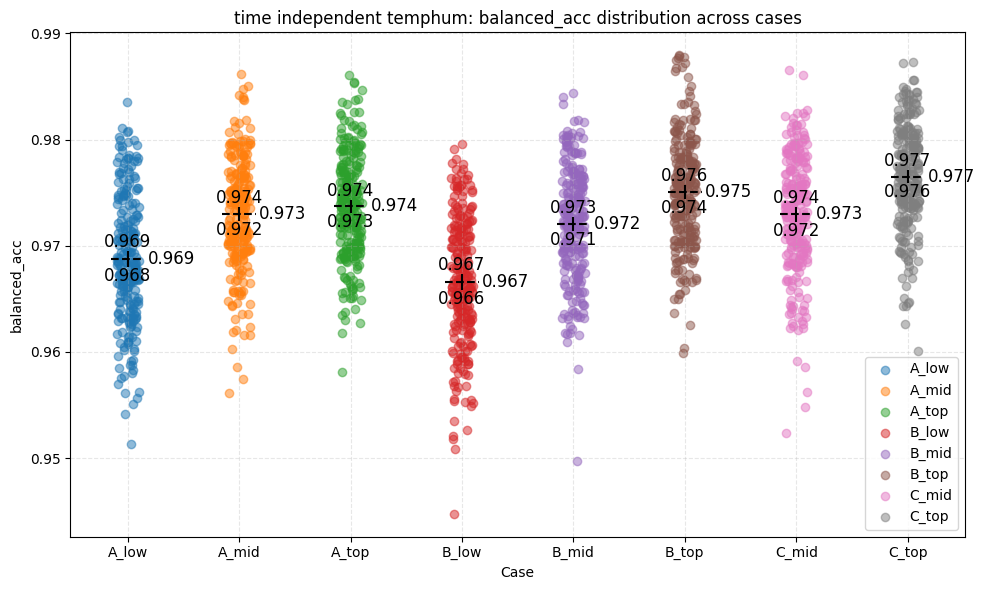

In [165]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

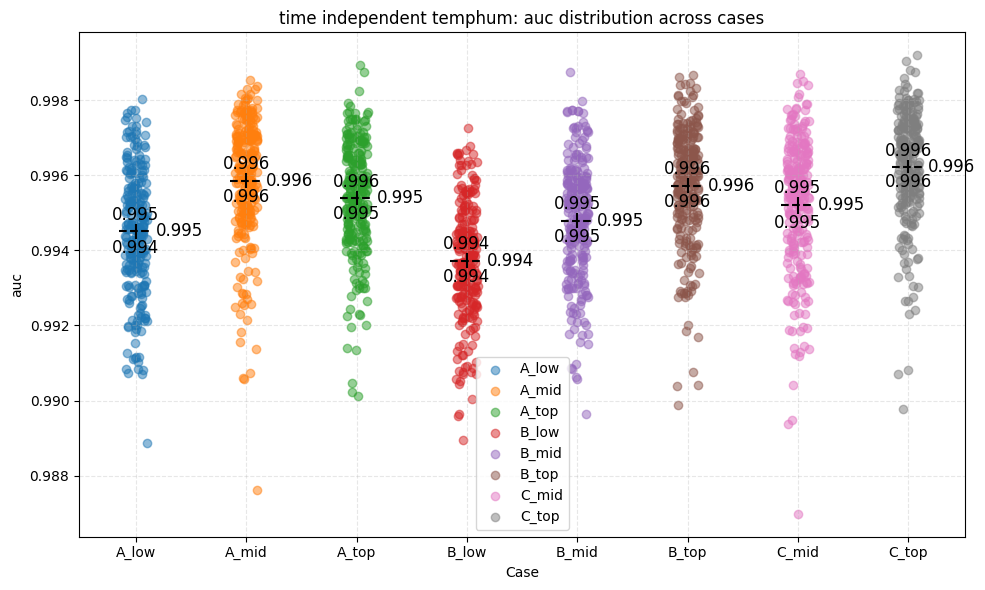

In [166]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [167]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time independent temphum

=== Normality test (D’Agostino and Pearson) for accuracy ===
A_low                    :	p = 0.4261	→	OK normal
A_mid                    :	p = 0.2900	→	OK normal
A_top                    :	p = 0.2498	→	OK normal
B_low                    :	p = 0.5053	→	OK normal
B_mid                    :	p = 0.1798	→	OK normal
B_top                    :	p = 0.3944	→	OK normal
C_mid                    :	p = 0.0068	→	not normal
C_top                    :	p = 0.3457	→	OK normal

=== Normality test (Shapiro-Wilk) for accuracy ===
A_low                    :	p = 0.1447	→	OK normal
A_mid                    :	p = 0.1200	→	OK normal
A_top                    :	p = 0.1044	→	OK normal
B_low                    :	p = 0.1973	→	OK normal
B_mid                    :	p = 0.0159	→	not normal
B_top                    :	p = 0.0818	→	OK normal
C_mid                    :	p = 0.0024	→	not normal
C_top                    :	p = 0.0975	→	OK normal

=== Normality test (Anderson-Darling) for accuracy ===
A_

In [168]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted',
    group_order=case_order
)

time independent temphum

=== Normality test (D’Agostino and Pearson) for f1_weighted ===
A_low                    :	p = 0.4274	→	OK normal
A_mid                    :	p = 0.2916	→	OK normal
A_top                    :	p = 0.2604	→	OK normal
B_low                    :	p = 0.4912	→	OK normal
B_mid                    :	p = 0.1858	→	OK normal
B_top                    :	p = 0.4011	→	OK normal
C_mid                    :	p = 0.0063	→	not normal
C_top                    :	p = 0.3476	→	OK normal

=== Normality test (Shapiro-Wilk) for f1_weighted ===
A_low                    :	p = 0.1916	→	OK normal
A_mid                    :	p = 0.1733	→	OK normal
A_top                    :	p = 0.1785	→	OK normal
B_low                    :	p = 0.2565	→	OK normal
B_mid                    :	p = 0.0245	→	not normal
B_top                    :	p = 0.1223	→	OK normal
C_mid                    :	p = 0.0032	→	not normal
C_top                    :	p = 0.1369	→	OK normal

=== Normality test (Anderson-Darling) for f1_weight

In [169]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time independent temphum

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
A_low                    :	p = 0.5843	→	OK normal
A_mid                    :	p = 0.1250	→	OK normal
A_top                    :	p = 0.8507	→	OK normal
B_low                    :	p = 0.1392	→	OK normal
B_mid                    :	p = 0.0483	→	not normal
B_top                    :	p = 0.8612	→	OK normal
C_mid                    :	p = 0.0015	→	not normal
C_top                    :	p = 0.0556	→	OK normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
A_low                    :	p = 0.2719	→	OK normal
A_mid                    :	p = 0.1465	→	OK normal
A_top                    :	p = 0.9020	→	OK normal
B_low                    :	p = 0.0517	→	OK normal
B_mid                    :	p = 0.0258	→	not normal
B_top                    :	p = 0.3581	→	OK normal
C_mid                    :	p = 0.0024	→	not normal
C_top                    :	p = 0.0262	→	not normal

=== Normality test (Anderson-Darling) for balan

In [170]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time independent temphum

=== Normality test (D’Agostino and Pearson) for auc ===
A_low                    :	p = 0.1269	→	OK normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.1319	→	OK normal
B_mid                    :	p = 0.0461	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
A_low                    :	p = 0.0614	→	OK normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0001	→	not normal
B_low                    :	p = 0.0568	→	OK normal
B_mid                    :	p = 0.0426	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for auc ===
A_low   

### ANOVA

In [171]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time independent temphum

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2          F         p-unc      np2
  case      7 853.349176 107.619323 9.701224e-113 0.286234

Effect size (partial η², np2) = 0.2862 → large effect

=== Games-Howell post-hoc test for accuracy ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.972776 0.976817 -0.004042 0.000418  -9.673979 488.366147 0.000000e+00 -0.863963
A_low A_top 0.972776 0.977010 -0.004235 0.000409 -10.364730 480.209411 9.492407e-14 -0.925653
A_low B_low 0.972776 0.970700  0.002076 0.000441   4.710729 497.678351 8.682171e-05  0.420706
A_low B_mid 0.972776 0.975418 -0.002642 0.000418  -6.327630 488.165516 1.575631e-08 -0.565108
A_low B_top 0.972776 0.978996 -0.006220 0.000412 -15.092677 483.696095 0.000000e+00 -1.347896
A_low C_mid 0.972776 0.976428 -0.003652 0.000430  -8.491561 495.136923 1.264544e-13 -0.758364
A_low C_top 0.972776 0.979656 -0.006880 0.000405 -17.007899 4

In [172]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted'
)

time independent temphum

=== Welch ANOVA for f1_weighted ===
Source  ddof1      ddof2          F         p-unc      np2
  case      7 853.346704 107.029276 2.888863e-112 0.285331

Effect size (partial η², np2) = 0.2853 → large effect

=== Games-Howell post-hoc test for f1_weighted ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.972760 0.976798 -0.004038 0.000418  -9.652102 488.305469 0.000000e+00 -0.862009
A_low A_top 0.972760 0.977003 -0.004243 0.000409 -10.371704 480.061281 0.000000e+00 -0.926276
A_low B_low 0.972760 0.970689  0.002071 0.000442   4.691844 497.706203 9.476625e-05  0.419019
A_low B_mid 0.972760 0.975412 -0.002652 0.000418  -6.341900 488.140538 1.446652e-08 -0.566382
A_low B_top 0.972760 0.978969 -0.006209 0.000413 -15.035012 483.869540 0.000000e+00 -1.342746
A_low C_mid 0.972760 0.976417 -0.003657 0.000431  -8.489027 495.137342 1.186828e-13 -0.758138
A_low C_top 0.972760 0.979645 -0.006884 0.000405 -16.99

In [173]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time independent temphum

=== Welch ANOVA for balanced_acc ===
Source  ddof1     ddof2         F        p-unc      np2
  case      7 853.35942 81.777638 8.962926e-91 0.236885

Effect size (partial η², np2) = 0.2369 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.968735 0.973012 -0.004277 0.000504  -8.482176 489.040111 0.000000e+00 -0.757526
A_low A_top 0.968735 0.973727 -0.004992 0.000494 -10.108152 481.763530 1.704192e-13 -0.902738
A_low B_low 0.968735 0.966610  0.002126 0.000541   3.929390 497.907672 2.452477e-03  0.350926
A_low B_mid 0.968735 0.972053 -0.003318 0.000509  -6.513693 491.776013 5.075783e-09 -0.581725
A_low B_top 0.968735 0.975074 -0.006338 0.000506 -12.525277 490.076658 0.000000e+00 -1.118607
A_low C_mid 0.968735 0.972962 -0.004227 0.000520  -8.126172 495.783812 1.995071e-13 -0.725732
A_low C_top 0.968735 0.976520 -0.007784 0.000491 -15.839015

In [174]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time independent temphum

=== Welch ANOVA for auc ===
Source  ddof1      ddof2         F        p-unc      np2
  case      7 853.446773 69.625831 1.746975e-79 0.184738

Effect size (partial η², np2) = 0.1847 → large effect

=== Games-Howell post-hoc test for auc ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.994506 0.995852 -0.001346 0.000148  -9.115366 497.974892 0.000000e+00 -0.814075
A_low A_top 0.994506 0.995393 -0.000887 0.000141  -6.271475 493.215735 2.185310e-08 -0.560093
A_low B_low 0.994506 0.993725  0.000781 0.000142   5.487772 494.560315 1.805855e-06  0.490102
A_low B_mid 0.994506 0.994792 -0.000286 0.000145  -1.968919 497.204258 5.040788e-01 -0.175840
A_low B_top 0.994506 0.995723 -0.001217 0.000144  -8.460163 496.119269 0.000000e+00 -0.755560
A_low C_mid 0.994506 0.995201 -0.000695 0.000156  -4.466683 493.689965 2.629069e-04 -0.398910
A_low C_top 0.994506 0.996228 -0.001722 0.000140 -12.320536 490.345163 0.00

## Time series - temphum

In [175]:
model = "time series temphum"
A_low = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_A_low_state_timeseries_temphum.csv")
A_mid = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_A_mid_state_timeseries_temphum.csv")
A_top = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_A_top_state_timeseries_temphum.csv")
B_low = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_B_low_state_timeseries_temphum.csv")
B_mid = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_B_mid_state_timeseries_temphum.csv")
B_top = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_B_top_state_timeseries_temphum.csv")
C_mid = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_C_mid_state_timeseries_temphum.csv")
C_top = pd.read_csv(
    "../_timeseries_results_raw/case_LabEEE_C_top_state_timeseries_temphum.csv")


In [176]:
A_low.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.823533,0.137404,0.422535,0.792046,0.883181,0.917978,0.964374
f1,250.0,0.738253,0.296435,0.000000,0.743289,0.874108,0.912241,0.962048
balanced_acc,250.0,0.816784,0.146422,0.451590,0.783063,0.882672,0.917177,0.964604
auc,250.0,0.904941,0.114243,0.431731,0.902716,0.948088,0.976001,0.992046
feature_importance.A_low_temperature_scaled,250.0,-0.003113,0.008471,-0.034880,-0.006545,-0.000994,0.000746,0.031980
feature_importance.A_low_temperature_fd1_scaled,250.0,0.010942,0.014678,-0.014913,0.001201,0.007954,0.016591,0.143496
feature_importance.A_low_temperature_fd2_scaled,250.0,0.012725,0.016685,-0.015079,0.000766,0.009735,0.018724,0.171914
feature_importance.A_low_temperature_fd3_scaled,250.0,0.012654,0.016425,-0.024109,0.000849,0.009528,0.018724,0.159901


In [177]:
A_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.924190,0.019492,0.815422,0.915505,0.927810,0.936833,0.958162
f1,250.0,0.915379,0.025759,0.754098,0.904519,0.921052,0.932080,0.954747
balanced_acc,250.0,0.922165,0.021735,0.801487,0.911970,0.926399,0.936765,0.957758
auc,250.0,0.974924,0.007138,0.936841,0.970588,0.976074,0.979666,0.989034
feature_importance.A_mid_temperature_scaled,250.0,-0.001319,0.005090,-0.029943,-0.003856,-0.000984,0.001313,0.012059
feature_importance.A_mid_temperature_fd1_scaled,250.0,0.019520,0.022679,-0.022642,0.005578,0.013002,0.027646,0.111157
feature_importance.A_mid_temperature_fd2_scaled,250.0,0.016187,0.022867,-0.024282,0.001661,0.011485,0.022498,0.119524
feature_importance.A_mid_temperature_fd3_scaled,250.0,0.013672,0.022869,-0.019196,0.000984,0.006850,0.018868,0.143560


In [178]:
A_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.933246,0.021266,0.853355,0.921292,0.938691,0.947804,0.972659
f1,250.0,0.924920,0.026541,0.815817,0.912134,0.932094,0.942459,0.970297
balanced_acc,250.0,0.930558,0.022948,0.843477,0.918507,0.936397,0.945812,0.971698
auc,250.0,0.986006,0.007170,0.947644,0.982397,0.987734,0.991254,0.995568
feature_importance.A_top_temperature_scaled,250.0,0.002163,0.005674,-0.014996,-0.001574,0.002527,0.005841,0.018144
feature_importance.A_top_temperature_fd1_scaled,250.0,0.019072,0.012811,-0.011848,0.010273,0.018268,0.027009,0.063546
feature_importance.A_top_temperature_fd2_scaled,250.0,0.013737,0.011650,-0.012593,0.004619,0.012759,0.022846,0.049461
feature_importance.A_top_temperature_fd3_scaled,250.0,0.008756,0.010225,-0.020630,0.001243,0.008326,0.015410,0.035708


In [179]:
B_low.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.931026,0.049408,0.658658,0.930406,0.945319,0.955261,0.981773
f1,250.0,0.921207,0.071932,0.437158,0.924149,0.942342,0.952128,0.980357
balanced_acc,250.0,0.929707,0.052549,0.635108,0.928635,0.945842,0.955373,0.981355
auc,250.0,0.981598,0.019224,0.861928,0.980424,0.986935,0.991077,0.996845
feature_importance.B_low_temperature_scaled,250.0,-0.000081,0.006176,-0.058575,-0.002237,0.000207,0.002258,0.033803
feature_importance.B_low_temperature_fd1_scaled,250.0,0.017468,0.016579,-0.011765,0.005592,0.014250,0.026740,0.096355
feature_importance.B_low_temperature_fd2_scaled,250.0,0.019269,0.018086,-0.013007,0.006711,0.015120,0.027962,0.117233
feature_importance.B_low_temperature_fd3_scaled,250.0,0.018112,0.017978,-0.011848,0.005841,0.013877,0.027092,0.116901


In [180]:
B_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.756603,0.166516,0.462490,0.534213,0.825227,0.909110,0.963726
f1,250.0,0.575612,0.388640,0.000000,0.003524,0.808997,0.902458,0.961199
balanced_acc,250.0,0.743686,0.180599,0.489659,0.500000,0.826017,0.908188,0.963782
auc,250.0,0.839392,0.162882,0.196459,0.763235,0.906830,0.956602,0.992617
feature_importance.B_mid_temperature_scaled,250.0,-0.000406,0.009752,-0.065870,-0.002102,0.000000,0.001546,0.073949
feature_importance.B_mid_temperature_fd1_scaled,250.0,0.014630,0.022445,-0.051278,0.000000,0.007914,0.022836,0.192910
feature_importance.B_mid_temperature_fd2_scaled,250.0,0.016666,0.024185,-0.045754,0.000000,0.009110,0.026134,0.188541
feature_importance.B_mid_temperature_fd3_scaled,250.0,0.016264,0.023484,-0.059275,0.000000,0.010882,0.027288,0.173949


In [181]:
B_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.935387,0.030914,0.748964,0.924814,0.946147,0.954432,0.969345
f1,250.0,0.928342,0.039570,0.680042,0.917317,0.942569,0.951284,0.967458
balanced_acc,250.0,0.934089,0.033002,0.737831,0.923003,0.946236,0.954423,0.969821
auc,250.0,0.981431,0.020549,0.735950,0.980092,0.984997,0.989305,0.996266
feature_importance.B_top_temperature_scaled,250.0,0.002192,0.007133,-0.030075,-0.001388,0.001450,0.005261,0.027589
feature_importance.B_top_temperature_fd1_scaled,250.0,0.020819,0.016251,-0.013256,0.008554,0.018600,0.031297,0.074068
feature_importance.B_top_temperature_fd2_scaled,250.0,0.017000,0.015194,-0.009196,0.005820,0.014954,0.024917,0.067606
feature_importance.B_top_temperature_fd3_scaled,250.0,0.012713,0.014222,-0.020713,0.002154,0.009942,0.019925,0.065866


In [182]:
C_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.865637,0.061807,0.548811,0.847826,0.883921,0.904840,0.941756
f1,250.0,0.833047,0.109366,0.051724,0.814740,0.867925,0.892670,0.937224
balanced_acc,250.0,0.859113,0.066865,0.513274,0.839032,0.879777,0.901359,0.941504
auc,250.0,0.954840,0.041380,0.582603,0.952907,0.967737,0.973671,0.986785
feature_importance.C_mid_temperature_scaled,250.0,-0.003898,0.007329,-0.025759,-0.008203,-0.003856,-0.000103,0.028302
feature_importance.C_mid_temperature_fd1_scaled,250.0,0.011573,0.008816,-0.013536,0.006112,0.010500,0.015546,0.059557
feature_importance.C_mid_temperature_fd2_scaled,250.0,0.011756,0.010421,-0.008696,0.005168,0.009229,0.015484,0.058491
feature_importance.C_mid_temperature_fd3_scaled,250.0,0.011644,0.010742,-0.010008,0.004799,0.009680,0.015730,0.056030


In [183]:
C_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.923453,0.040490,0.677659,0.917766,0.937345,0.947238,0.967848
f1,250.0,0.913313,0.055275,0.505689,0.907083,0.932629,0.943505,0.965939
balanced_acc,250.0,0.921550,0.043460,0.656929,0.914293,0.936948,0.947114,0.968547
auc,250.0,0.976985,0.018823,0.807724,0.975701,0.981551,0.986829,0.994226
feature_importance.C_top_temperature_scaled,250.0,-0.002459,0.004999,-0.021022,-0.004843,-0.002061,0.000577,0.015004
feature_importance.C_top_temperature_fd1_scaled,250.0,0.013006,0.008975,-0.016653,0.007214,0.012407,0.018178,0.036109
feature_importance.C_top_temperature_fd2_scaled,250.0,0.011311,0.008503,-0.024073,0.006286,0.010800,0.016550,0.033883
feature_importance.C_top_temperature_fd3_scaled,250.0,0.009444,0.008557,-0.028854,0.004534,0.009439,0.014468,0.035779


In [184]:
A_low['case'] = 'A_low'
A_mid['case'] = 'A_mid'
A_top['case'] = 'A_top'
B_low['case'] = 'B_low'
B_mid['case'] = 'B_mid'
B_top['case'] = 'B_top'
C_mid['case'] = 'C_mid'
C_top['case'] = 'C_top'

metrics = ["case", "accuracy", "f1", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        A_low[metrics],
        A_mid[metrics],
        A_top[metrics],
        B_low[metrics],
        B_mid[metrics],
        B_top[metrics],
        C_mid[metrics],
        C_top[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          2000 non-null   object 
 1   accuracy      2000 non-null   float64
 2   f1            2000 non-null   float64
 3   balanced_acc  2000 non-null   float64
 4   auc           2000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 78.3+ KB


In [185]:
case_order = ['A_low', 'A_mid', 'A_top', 'B_low', 'B_mid', 'B_top', 'C_mid', 'C_top']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,A_low,A_low,A_low,A_low,A_low
accuracy,0.576636,0.899751,0.89478,0.755592,0.927092
f1,0.169106,0.881256,0.88771,0.645858,0.917293
balanced_acc,0.546181,0.893322,0.894584,0.738122,0.923299
auc,0.859775,0.985333,0.93131,0.926428,0.982696
x,0,0,0,0,0
x_jitter,0.067262,-0.026092,0.021072,-0.084792,-0.042516


### plot

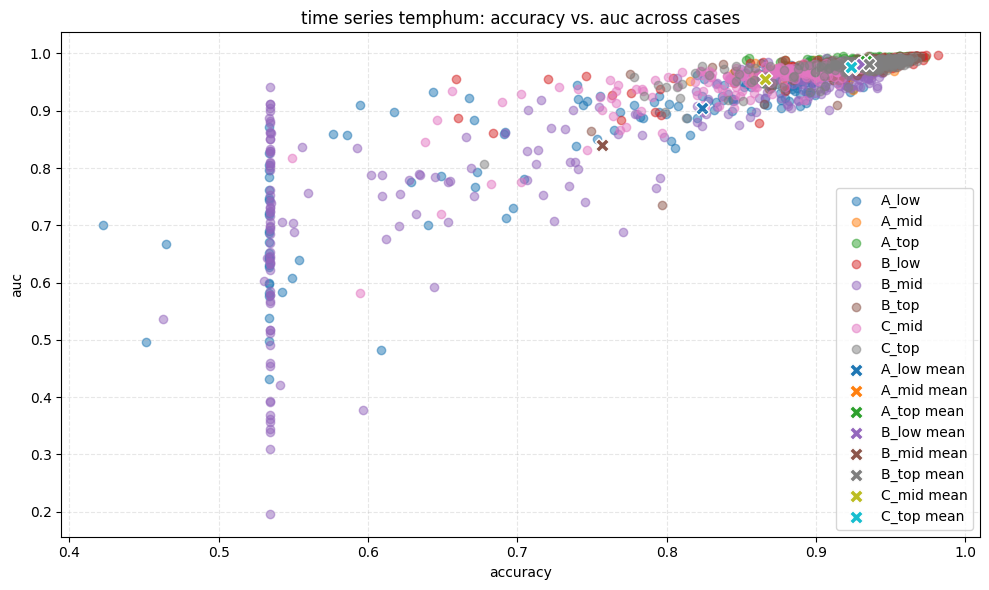

In [186]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

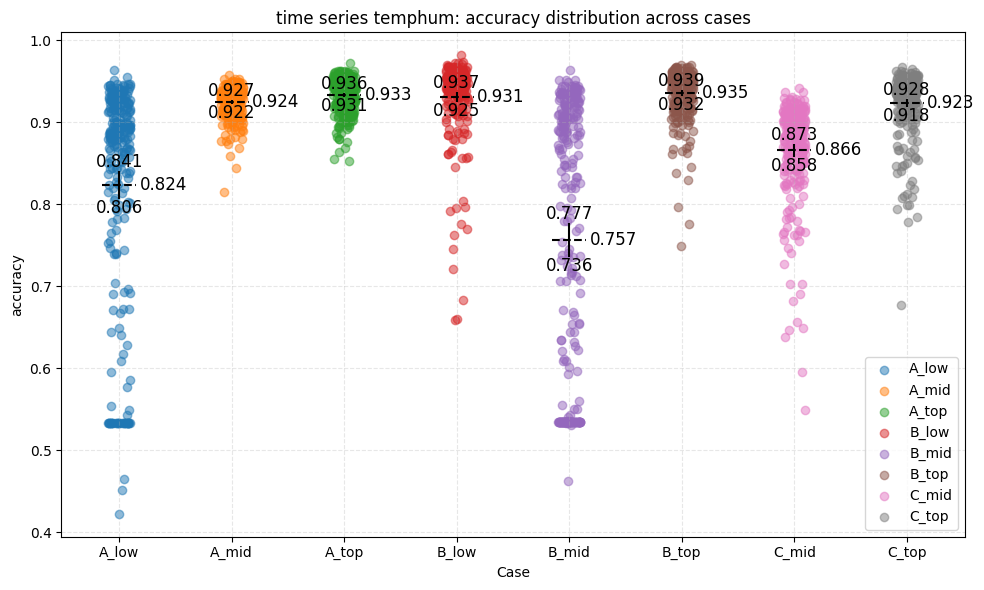

In [187]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

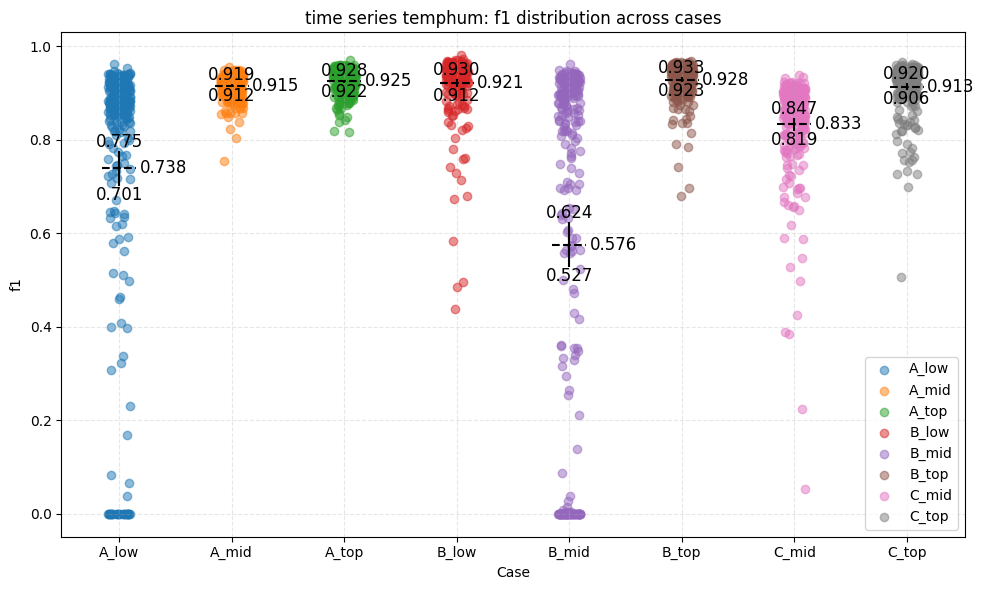

In [188]:
# plot f1 score
metric = "f1"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

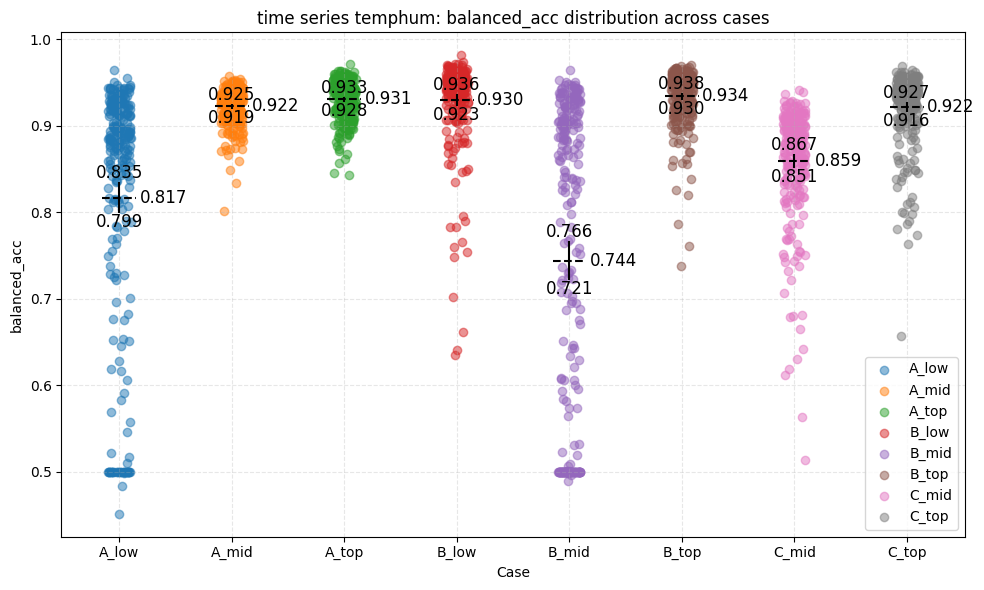

In [189]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

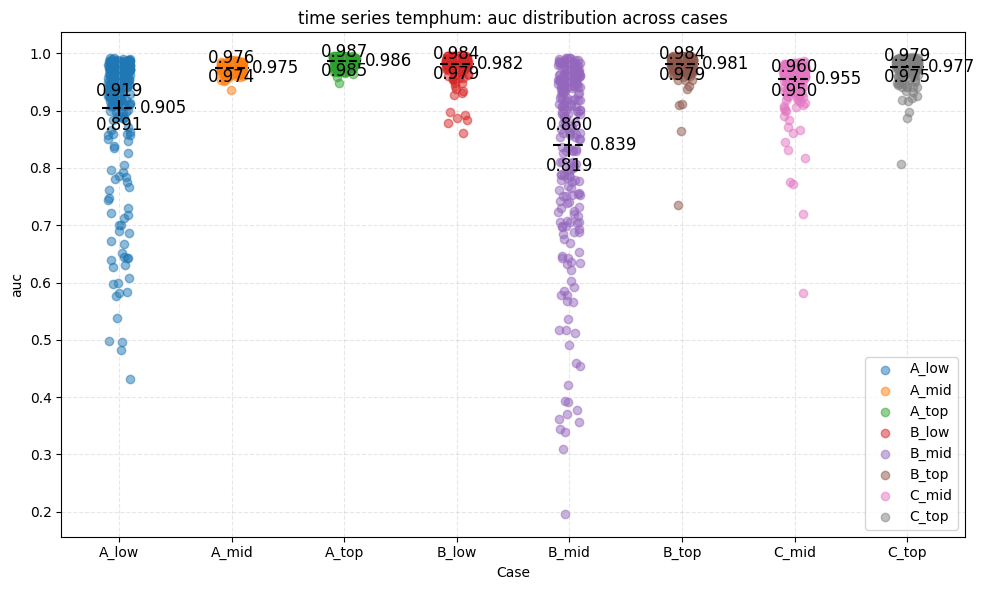

In [190]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [191]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time series temphum

=== Normality test (D’Agostino and Pearson) for accuracy ===
A_low                    :	p = 0.0000	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.0000	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for accuracy ===
A_low                    :	p = 0.0000	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.0000	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for accurac

In [192]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1',
    group_order=case_order
)

time series temphum

=== Normality test (D’Agostino and Pearson) for f1 ===
A_low                    :	p = 0.0000	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.0000	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for f1 ===
A_low                    :	p = 0.0000	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.0000	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for f1 ===
A_low       

In [193]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time series temphum

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
A_low                    :	p = 0.0000	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.0000	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
A_low                    :	p = 0.0000	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.0000	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for

In [194]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time series temphum

=== Normality test (D’Agostino and Pearson) for auc ===
A_low                    :	p = 0.0000	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.0000	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
A_low                    :	p = 0.0000	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0000	→	not normal
B_low                    :	p = 0.0000	→	not normal
B_mid                    :	p = 0.0000	→	not normal
B_top                    :	p = 0.0000	→	not normal
C_mid                    :	p = 0.0000	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for auc ===
A_low    

### ANOVA

In [195]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time series temphum

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2         F         p-unc      np2
  case      7 835.758755 98.510297 9.816231e-105 0.353185

Effect size (partial η², np2) = 0.3532 → large effect

=== Games-Howell post-hoc test for accuracy ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.823533 0.924190 -0.100658 0.008777 -11.468040 259.017608 7.449596e-14 -1.024187
A_low A_top 0.823533 0.933246 -0.109713 0.008794 -12.476371 260.922294 0.000000e+00 -1.114239
A_low B_low 0.823533 0.931026 -0.107493 0.009235 -11.639772 312.332494 2.375877e-14 -1.039524
A_low B_mid 0.823533 0.756603  0.066929 0.013654   4.901829 480.678521 3.551145e-05  0.437772
A_low B_top 0.823533 0.935387 -0.111854 0.008907 -12.557377 274.143302 1.071365e-13 -1.121474
A_low C_mid 0.823533 0.865637 -0.042105 0.009529  -4.418617 345.800818 3.524745e-04 -0.394618
A_low C_top 0.823533 0.923453 -0.099920 0.009060 -11.029078 291.9201

In [196]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1'
)

time series temphum

=== Welch ANOVA for f1 ===
Source  ddof1      ddof2        F        p-unc      np2
  case      7 833.125935 67.64066 3.337792e-77 0.301878

Effect size (partial η², np2) = 0.3019 → large effect

=== Games-Howell post-hoc test for f1 ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.738253 0.915379 -0.177126 0.018819  -9.412189 252.760264 7.616130e-14 -0.840583
A_low A_top 0.738253 0.924920 -0.186667 0.018823  -9.916899 252.991903 7.271961e-14 -0.885658
A_low B_low 0.738253 0.921207 -0.182954 0.019292  -9.483318 278.222239 9.992007e-15 -0.846936
A_low B_mid 0.738253 0.575612  0.162641 0.030914   5.261113 465.462230 6.041834e-06  0.469859
A_low B_top 0.738253 0.928342 -0.190090 0.018914 -10.049968 257.871015 0.000000e+00 -0.897542
A_low C_mid 0.738253 0.833047 -0.094794 0.019983  -4.743639 315.551895 8.604633e-05 -0.423645
A_low C_top 0.738253 0.913313 -0.175060 0.019071  -9.179239 266.294489 9.181544e-14 

In [197]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time series temphum

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2         F         p-unc      np2
  case      7 836.600102 94.731687 1.311716e-101 0.346273

Effect size (partial η², np2) = 0.3463 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.816784 0.922165 -0.105381 0.009362 -11.256234 259.967836 0.000000e+00 -1.005271
A_low A_top 0.816784 0.930558 -0.113773 0.009374 -12.137696 261.224574 2.553513e-14 -1.083993
A_low B_low 0.816784 0.929707 -0.112922 0.009839 -11.477203 312.094956 0.000000e+00 -1.025005
A_low B_mid 0.816784 0.743686  0.073099 0.014704   4.971176 477.582241 2.543924e-05  0.443966
A_low B_top 0.816784 0.934089 -0.117304 0.009493 -12.357126 274.234265 0.000000e+00 -1.103590
A_low C_mid 0.816784 0.859113 -0.042329 0.010180  -4.157874 348.523223 1.046343e-03 -0.371331
A_low C_top 0.816784 0.921550 -0.104765 0.009660 -10.845452 

In [198]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time series temphum

=== Welch ANOVA for auc ===
Source  ddof1      ddof2        F         p-unc      np2
  case      7 824.070838 99.14709 7.012308e-105 0.308685

Effect size (partial η², np2) = 0.3087 → large effect

=== Games-Howell post-hoc test for auc ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.904941 0.974924 -0.069983 0.007239  -9.666916 250.944066 1.200151e-13 -0.863332
A_low A_top 0.904941 0.986006 -0.081065 0.007240 -11.197488 250.961303 0.000000e+00 -1.000025
A_low B_low 0.904941 0.981598 -0.076657 0.007327 -10.462398 263.090456 0.000000e+00 -0.934375
A_low B_mid 0.904941 0.839392  0.065549 0.012583   5.209403 446.250866 7.992856e-06  0.465241
A_low B_top 0.904941 0.981431 -0.076490 0.007341 -10.419106 265.095835 1.648681e-13 -0.930509
A_low C_mid 0.904941 0.954840 -0.049899 0.007685  -6.493255 313.230920 9.195067e-09 -0.579899
A_low C_top 0.904941 0.976985 -0.072044 0.007323  -9.838422 262.508628 0.000000e